# Exploratory Data Analysis: Healthy Operation Baseline

## Business Context & Objectives

### Project Goal
Develop a predictive maintenance system for SAM Automation's robotic pick-and-place operations to reduce unplanned downtime and maintenance costs.

### Key Business Failure Modes (from BRD)
This analysis focuses on establishing baselines for detecting three critical failure types:

| Failure Mode | Business Impact | Target Features | Detection Strategy |
|--------------|-----------------|-----------------|-------------------|
| **Vacuum Suction Failure** | Failed pick-and-place → production stoppage | `pressure` | Monitor pressure drops |
| **Mechanical Wear/Degradation** | Gradual performance loss → quality issues | `vib_mean`, `vib_max`, `dominant_freq`, FFT bins (1.6-98.4 Hz) | Detect vibration pattern changes |
| **Thermal Overload** | Motor burnout → expensive repairs | `avg_motor_temp`, `max_motor_temp` | Monitor temperature trends |

### Analysis Objectives
This notebook establishes the operational baseline for the Niryo Ned2 robotic arm by analyzing data from healthy (fault-free) sessions. Understanding normal behavior patterns is critical for:
- **Defining anomaly detection thresholds** aligned with business failure modes
- **Identifying relevant features** that predict the failure types above
- **Validating data quality** before model training
- **Selecting and preprocessing data** using filter, wrapper, and embedded methods

---

## Healthy Sessions Analyzed
Based on the data collection log (in the README.md), the following sessions represent healthy (baseline) operations:
- `20251106_100119` - First data collection test
- `20251106_104222` - Short healthy loop (5Hz sampling)
- `20251106_114228` - Medium-length healthy loop (2.5Hz)
- `20251106_154758` - Short healthy loop (10Hz)
- `20251106_161257` - Medium-length healthy loop with laptop sleep interruption
- `20251112_145646` - Longer healthy loop
- `20251204_155627` - Long healthy loop

**Total**: 7 healthy sessions spanning ~1 month of data collection

---

## Data Structure
- **92 columns**: 6 joint positions, 9 temperatures, 7 voltages, 1 error state, 1 pressure, 66 vibration features (4 summary + 1 dominant frequency + 61 FFT spectrum bins)
- **Sampling Rate**: ~2.5 Hz (unified timeline from robot telemetry)
- **Format**: Apache Parquet with nanosecond-precision timestamps

### Feature Groups Aligned with Business Objectives

| Feature Group | Column Count | Key Variables | Business Purpose |
|---------------|--------------|---------------|------------------|
| **Pressure** | 1 | `pressure` | Primary indicator for vacuum suction failures |
| **Vibration Summary** | 4 | `vib_mean`, `vib_max`, `vib_min`, `dominant_freq` | Quick mechanical health indicators |
| **Vibration FFT Spectrum** | 61 | `vib_1.6` ... `vib_98.4` | Frequency-specific mechanical wear detection |
| **Joint Positions** | 6 | `j1`, `j2`, `j3`, `j4`, `j5`, `j6` | Movement anomaly detection |
| **Motor Temperatures** | 9 | Individual motors + `avg_motor_temp`, `max_motor_temp`, `rpi_temp` | Thermal overload prevention |
| **Motor Voltages** | 7 | Individual motors + `avg_motor_voltage` | Power consumption monitoring |
| **System State** | 1 | `error_state` | Error validation |
| **Temporal** | 1 | `timestamp` | Time-series alignment |

**Total**: 92 columns = 1 timestamp + 91 features

## 1. Environment Setup & Data Discovery

Setting up the analysis environment and discovering all available healthy session files.

This section demonstrates **data selection** by identifying and filtering relevant healthy sessions from the complete dataset.

In [23]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import glob
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [24]:
# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

# Healthy session identifiers from codebook
HEALTHY_SESSIONS = [
    '20251106_100119',
    '20251106_104222',
    '20251106_114228',
    '20251106_154758',
    '20251106_161257',
    '20251112_145646',
    '20251204_155627'
]

print("="*70)
print("DISCOVERING HEALTHY DATA FILES")
print("="*70)

# Get all unified files
unified_files = sorted(glob.glob('../data/*/robot_data_unified_*.parquet'))
print(f"\n✓ Found {len(unified_files)} total unified data files")

# Filter for healthy sessions
healthy_files = [f for f in unified_files if any(session in f for session in HEALTHY_SESSIONS)]
print(f"✓ Identified {len(healthy_files)} healthy session files\n")

print(f"Healthy sessions:")
for i, f in enumerate(healthy_files, 1):
    session = Path(f).parent.name
    file_size = Path(f).stat().st_size / (1024**2)  # Convert to MB
    print(f"  {i}. Session {session} ({file_size:.2f} MB)")


DISCOVERING HEALTHY DATA FILES

✓ Found 17 total unified data files
✓ Identified 7 healthy session files

Healthy sessions:
  1. Session 20251106_100119 (0.08 MB)
  2. Session 20251106_104222 (0.87 MB)
  3. Session 20251106_114228 (1.06 MB)
  4. Session 20251106_154758 (0.53 MB)
  5. Session 20251106_161257 (0.80 MB)
  6. Session 20251112_145646 (1.26 MB)
  7. Session 20251204_155627 (3.19 MB)


## 1B. Feature-to-Business Objective Mapping

Before analyzing the data, we explicitly map each feature group to business failure modes to ensure our analysis remains focused on business-relevant signals.

In [27]:
print("="*70)
print("BUSINESS OBJECTIVE - FEATURE MAPPING")
print("="*70)

# Define business-driven feature selection
business_feature_map = {
    'Vacuum Suction Failure Detection': {
        'Critical Features': ['pressure'],
        'Supporting Features': ['error_state'],
        'Rationale': 'Direct measurement of suction strength; error_state flags system issues',
        'Business Impact': 'Prevents failed pick-and-place operations'
    },
    
    'Mechanical Wear Detection': {
        'Critical Features': ['vib_mean', 'vib_max', 'dominant_freq'],
        'Supporting Features': ['vib_1.6', 'vib_3.2', '...', 'vib_98.4'],  # FFT spectrum
        'Rationale': 'Vibration patterns change with bearing/joint degradation',
        'Business Impact': 'Early warning before mechanical failure'
    },
    
    'Thermal Overload Prevention': {
        'Critical Features': ['avg_motor_temp', 'max_motor_temp'],
        'Supporting Features': ['motor1_temp', 'motor2_temp', 'motor3_temp', 
                                'motor4_temp', 'motor5_temp', 'motor6_temp', 'rpi_temp'],
        'Rationale': 'Temperature trends indicate overheating risk',
        'Business Impact': 'Prevents motor burnout and expensive repairs'
    },
    
    'Movement Anomaly Detection': {
        'Critical Features': ['j1', 'j2', 'j3'],
        'Supporting Features': ['j4', 'j5', 'j6'],
        'Rationale': 'Unusual joint positions indicate calibration/control issues',
        'Business Impact': 'Maintains positioning accuracy for pick-and-place'
    },
    
    'Power Consumption Monitoring': {
        'Critical Features': ['avg_motor_voltage'],
        'Supporting Features': ['motor1_voltage', 'motor2_voltage', 'motor3_voltage',
                                'motor4_voltage', 'motor5_voltage', 'motor6_voltage'],
        'Rationale': 'Voltage spikes/drops indicate electrical issues',
        'Business Impact': 'Detects power supply problems before system failure'
    }
}

# Display mapping
print("\nFeature selection is driven by business failure modes:\n")
for failure_mode, details in business_feature_map.items():
    print(f"{'='*70}")
    print(f"{failure_mode}")
    print(f"{'='*70}")
    print(f"Critical Features: {', '.join(details['Critical Features'])}")
    print(f"Supporting Features: {len(details['Supporting Features'])} additional features")
    print(f"Rationale: {details['Rationale']}")
    print(f"Business Impact: {details['Business Impact']}\n")

# Count total features selected
all_critical = []
for details in business_feature_map.values():
    all_critical.extend(details['Critical Features'])

unique_critical = set(all_critical)

print("="*70)
print("FEATURE SELECTION SUMMARY")
print("="*70)
print(f"Total business-driven feature groups: {len(business_feature_map)}")
print(f"Total critical features identified: {len(unique_critical)}")
print(f"Total features in dataset: 92")
print(f"\n✓ Analysis will prioritize the {len(unique_critical)} critical features")
print(f"✓ Supporting features used for detailed investigation when needed")

BUSINESS OBJECTIVE - FEATURE MAPPING

Feature selection is driven by business failure modes:

Vacuum Suction Failure Detection
Critical Features: pressure
Supporting Features: 1 additional features
Rationale: Direct measurement of suction strength; error_state flags system issues
Business Impact: Prevents failed pick-and-place operations

Mechanical Wear Detection
Critical Features: vib_mean, vib_max, dominant_freq
Supporting Features: 4 additional features
Rationale: Vibration patterns change with bearing/joint degradation
Business Impact: Early warning before mechanical failure

Thermal Overload Prevention
Critical Features: avg_motor_temp, max_motor_temp
Supporting Features: 7 additional features
Rationale: Temperature trends indicate overheating risk
Business Impact: Prevents motor burnout and expensive repairs

Movement Anomaly Detection
Critical Features: j1, j2, j3
Supporting Features: 3 additional features
Rationale: Unusual joint positions indicate calibration/control issues
B

## 2. Session Overview & Temporal Coverage

Loading each healthy session and examining basic characteristics: duration, sample count, and data density.

In [3]:
print("="*70)
print("LOADING SESSIONS & COMPUTING BASIC STATISTICS")
print("="*70)

session_data = []
session_summary = []

for idx, file_path in enumerate(healthy_files, 1):
    session_id = Path(file_path).parent.name
    
    print(f"\n[{idx}/{len(healthy_files)}] Loading session: {session_id}")
    
    # Load data
    df = pd.read_parquet(file_path)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    
    # Calculate session characteristics
    duration = (df['timestamp'].max() - df['timestamp'].min()).total_seconds()
    duration_min = duration / 60
    sample_count = len(df)
    sampling_rate = sample_count / duration if duration > 0 else 0
    
    print(f"  ├─ Records: {sample_count:,}")
    print(f"  ├─ Duration: {duration_min:.2f} minutes ({duration:.0f} seconds)")
    print(f"  ├─ Sampling Rate: {sampling_rate:.2f} Hz")
    print(f"  └─ Columns: {len(df.columns)}")
    
    # Store for analysis
    session_data.append({
        'session_id': session_id,
        'dataframe': df,
        'file_path': file_path
    })
    
    session_summary.append({
        'Session': session_id,
        'Records': sample_count,
        'Duration_min': duration_min,
        'Sampling_Hz': sampling_rate,
        'Start_Time': df['timestamp'].min(),
        'End_Time': df['timestamp'].max(),
        'File_Size_MB': Path(file_path).stat().st_size / (1024**2)
    })

# Create summary dataframe
summary_df = pd.DataFrame(session_summary)
print(f"\n{'='*70}")
print("HEALTHY SESSIONS SUMMARY TABLE")
print(f"{'='*70}\n")
print(summary_df.to_string(index=False))

# Aggregate statistics
print(f"\n{'='*70}")
print("AGGREGATE STATISTICS")
print(f"{'='*70}")
print(f"Total Records: {summary_df['Records'].sum():,}")
print(f"Total Duration: {summary_df['Duration_min'].sum():.2f} minutes")
print(f"Average Session Length: {summary_df['Duration_min'].mean():.2f} ± {summary_df['Duration_min'].std():.2f} minutes")
print(f"Average Sampling Rate: {summary_df['Sampling_Hz'].mean():.2f} ± {summary_df['Sampling_Hz'].std():.2f} Hz")

LOADING SESSIONS & COMPUTING BASIC STATISTICS

[1/7] Loading session: 20251106_100119
  ├─ Records: 165
  ├─ Duration: 0.55 minutes (33 seconds)
  ├─ Sampling Rate: 4.98 Hz
  └─ Columns: 92

[2/7] Loading session: 20251106_104222
  ├─ Records: 4,527
  ├─ Duration: 15.17 minutes (910 seconds)
  ├─ Sampling Rate: 4.97 Hz
  └─ Columns: 92

[3/7] Loading session: 20251106_114228
  ├─ Records: 3,194
  ├─ Duration: 21.39 minutes (1283 seconds)
  ├─ Sampling Rate: 2.49 Hz
  └─ Columns: 92

[4/7] Loading session: 20251106_154758
  ├─ Records: 5,000
  ├─ Duration: 8.79 minutes (527 seconds)
  ├─ Sampling Rate: 9.48 Hz
  └─ Columns: 92

[5/7] Loading session: 20251106_161257
  ├─ Records: 2,406
  ├─ Duration: 17.11 minutes (1026 seconds)
  ├─ Sampling Rate: 2.34 Hz
  └─ Columns: 92

[6/7] Loading session: 20251112_145646
  ├─ Records: 3,846
  ├─ Duration: 25.77 minutes (1546 seconds)
  ├─ Sampling Rate: 2.49 Hz
  └─ Columns: 92

[7/7] Loading session: 20251204_155627
  ├─ Records: 9,825
  ├─ Dur

---

### Data Integration Summary

The 7 healthy sessions provide a comprehensive baseline dataset with substantial temporal coverage:

**Session Variability:**
- Duration ranges from 0.55 to 66.85 minutes, providing both short and extended operation samples
- Sampling rates vary between 2.34-9.48 Hz across sessions, reflecting different data collection configurations
- Total of 28,963 synchronized records across 155.62 minutes (2.59 hours)

**Data Integration Characteristics:**
- **Multiple sources combined:** Robot internal telemetry (joints, motors, system state) merged with external sensors (pressure, vibration)
- **Synchronization method:** Nearest-neighbor timestamp matching (±500ms tolerance) aligns 2.5 Hz robot data with 10 Hz sensor data
- **Unified timeline:** All data resampled to robot frequency (~2.5 Hz) for consistent time-series analysis

**Implications for baseline modeling:**
- Sufficient data volume (28,963 records) for establishing statistical baselines
- Varied session lengths capture both startup/shutdown and steady-state operation
- Different sampling rates across sessions indicate need for standardized preprocessing
- Combined data streams enable multi-modal anomaly detection (mechanical, thermal, pressure)

## 2B. Statistical Summary Across All Healthy Sessions

Comprehensive statistical overview of the complete healthy baseline dataset to establish normal operating ranges.

In [17]:
print("="*70)
print("COMPREHENSIVE STATISTICAL SUMMARY - ALL HEALTHY DATA")
print("="*70)

# Combine all healthy sessions
all_healthy = pd.concat([s['dataframe'] for s in session_data], ignore_index=True)
print(f"\nCombined Dataset: {len(all_healthy):,} total records from {len(session_data)} sessions\n")

# Select key feature groups for summary
feature_groups_summary = {
    'Joint Positions (radians)': [f'j{i}' for i in range(1, 7)],
    'Motor Temperatures (°C)': [f'motor{i}_temp' for i in range(1, 7)] + ['avg_motor_temp', 'max_motor_temp'],
    'Motor Voltages (V)': [f'motor{i}_voltage' for i in range(1, 7)] + ['avg_motor_voltage'],
    'Vibration Metrics': ['vib_mean', 'vib_max', 'vib_min', 'dominant_freq'],
    'Pressure (raw)': ['pressure']
}

# Generate summary for each group
for group_name, features in feature_groups_summary.items():
    available_features = [f for f in features if f in all_healthy.columns]
    
    if len(available_features) > 0:
        print(f"\n{'='*70}")
        print(f"{group_name}")
        print(f"{'='*70}")
        
        summary_stats = all_healthy[available_features].describe()
        
        # Add additional statistics
        summary_stats.loc['range'] = summary_stats.loc['max'] - summary_stats.loc['min']
        summary_stats.loc['cv_%'] = (summary_stats.loc['std'] / summary_stats.loc['mean']) * 100
        summary_stats.loc['iqr'] = summary_stats.loc['75%'] - summary_stats.loc['25%']
        
        print(summary_stats.round(3))

# Overall dataset characteristics
print(f"\n{'='*70}")
print("OVERALL DATASET CHARACTERISTICS")
print(f"{'='*70}")

total_duration = sum([
    (s['dataframe']['timestamp'].max() - s['dataframe']['timestamp'].min()).total_seconds()
    for s in session_data
])

print(f"\nTemporal Coverage:")
print(f"  • Total recording time: {total_duration/60:.2f} minutes ({total_duration/3600:.2f} hours)")
print(f"  • First timestamp: {all_healthy['timestamp'].min()}")
print(f"  • Last timestamp: {all_healthy['timestamp'].max()}")
print(f"  • Date range: {(all_healthy['timestamp'].max() - all_healthy['timestamp'].min()).days} days")

print(f"\nData Volume:")
print(f"  • Total records: {len(all_healthy):,}")
print(f"  • Total features: {len(all_healthy.columns)}")
print(f"  • Total data points: {all_healthy.size:,}")
print(f"  • Memory usage: {all_healthy.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print(f"\nData Density:")
print(f"  • Average records per session: {len(all_healthy)/len(session_data):,.0f}")
print(f"  • Average records per minute: {len(all_healthy)/(total_duration/60):.1f}")
print(f"  • Expected sampling rate: ~2.5 Hz")

COMPREHENSIVE STATISTICAL SUMMARY - ALL HEALTHY DATA

Combined Dataset: 28,963 total records from 7 sessions


Joint Positions (radians)
              j1         j2         j3         j4         j5         j6
count  28963.000  28963.000  28963.000  28963.000  28963.000  28963.000
mean       0.548     -0.511     -0.381     -0.073     -0.535     -0.250
std        0.772      0.206      0.408      0.104      0.174      0.284
min       -2.900     -0.900     -1.340     -0.347     -0.812     -0.577
25%       -0.037     -0.664     -0.690     -0.090     -0.697     -0.537
50%        0.389     -0.484     -0.564     -0.057     -0.572     -0.176
75%        1.419     -0.360     -0.177     -0.026     -0.376     -0.044
max        1.523      0.610      0.408      0.624      0.005      0.301
range      4.423      1.510      1.748      0.971      0.816      0.877
cv_%     140.956    -40.249   -107.193   -142.374    -32.408   -113.702
iqr        1.456      0.305      0.514      0.064      0.321      0.492

---

### Baseline Operating Characteristics

The statistical summary establishes normal operating ranges for each feature group:

**Joint Positions:**
- High variability (CV% = 32-141%) reflects diverse movement patterns during pick-and-place cycles
- J1 (base rotation) shows widest range (4.42 rad ≈ 253°), as expected for primary positioning joint
- Tighter ranges for wrist joints (j4-j6) indicate constrained end-effector movements

**Thermal Profile:**
- Motors operate at 40-52°C with low variability (CV% = 3-5%), indicating stable thermal conditions
- Motor 6 significantly cooler (24°C mean) - likely different motor type or lower load
- Temperature ranges (14-19°C) are narrow, suggesting consistent workload across sessions

**Power Consumption:**
- Motor voltages highly stable (CV% < 0.5%), ranging 11.0-12.0V for motors 1-5, 4.8-5.0V for motor 6
- Low variability indicates consistent power draw - no signs of electrical issues

**Vibration Characteristics:**
- Mean vibration: 0.136 Hz (range: 0.016-0.756 Hz) with moderate variability (CV% = 55%)
- Dominant frequency consistently near 1.6 Hz (IQR = 0), suggesting characteristic operational frequency
- Higher CV% in vibration expected due to varying movement phases (acceleration, steady motion, deceleration)

**Vacuum Pressure:**
- Mean: 31,367 raw units (range: 23,333-33,312), CV% = 3.6%
- Relatively stable pressure suggests consistent suction performance
- Lower quartile at 30,120 may represent moments without active suction

**Baseline Thresholds:**
These statistics will inform anomaly detection thresholds:
- Temperature alerts: >53°C (observed max) for individual motors
- Vibration alerts: >0.75 Hz mean (observed max + buffer)
- Pressure alerts: <25,000 (below observed safe range)

## 2C. Temporal Consistency & Sampling Rate Validation

Analyzing timestamp intervals and sampling consistency to identify potential data collection issues or irregularities.

SAMPLING RATE & TEMPORAL CONSISTENCY ANALYSIS

20251106_100119:
  ├─ Mean sampling interval: 0.202s (±0.008s)
  ├─ Actual sampling rate: 4.95 Hz (expected: 2.5 Hz)
  ├─ Deviation: +98.1%
  ├─ Interval range: 0.200s - 0.257s
  └─ Data gaps (>2s): 0

20251106_104222:
  ├─ Mean sampling interval: 0.201s (±0.003s)
  ├─ Actual sampling rate: 4.97 Hz (expected: 2.5 Hz)
  ├─ Deviation: +98.9%
  ├─ Interval range: 0.200s - 0.253s
  └─ Data gaps (>2s): 0

20251106_114228:
  ├─ Mean sampling interval: 0.402s (±0.006s)
  ├─ Actual sampling rate: 2.49 Hz (expected: 2.5 Hz)
  ├─ Deviation: -0.5%
  ├─ Interval range: 0.400s - 0.477s
  └─ Data gaps (>2s): 0

20251106_154758:
  ├─ Mean sampling interval: 0.105s (±0.018s)
  ├─ Actual sampling rate: 9.48 Hz (expected: 2.5 Hz)
  ├─ Deviation: +279.3%
  ├─ Interval range: 0.100s - 0.514s
  └─ Data gaps (>2s): 0

20251106_161257:
  ├─ Mean sampling interval: 0.427s (±1.019s)
  ├─ Actual sampling rate: 2.34 Hz (expected: 2.5 Hz)
  ├─ Deviation: -6.3%
  ├─ I

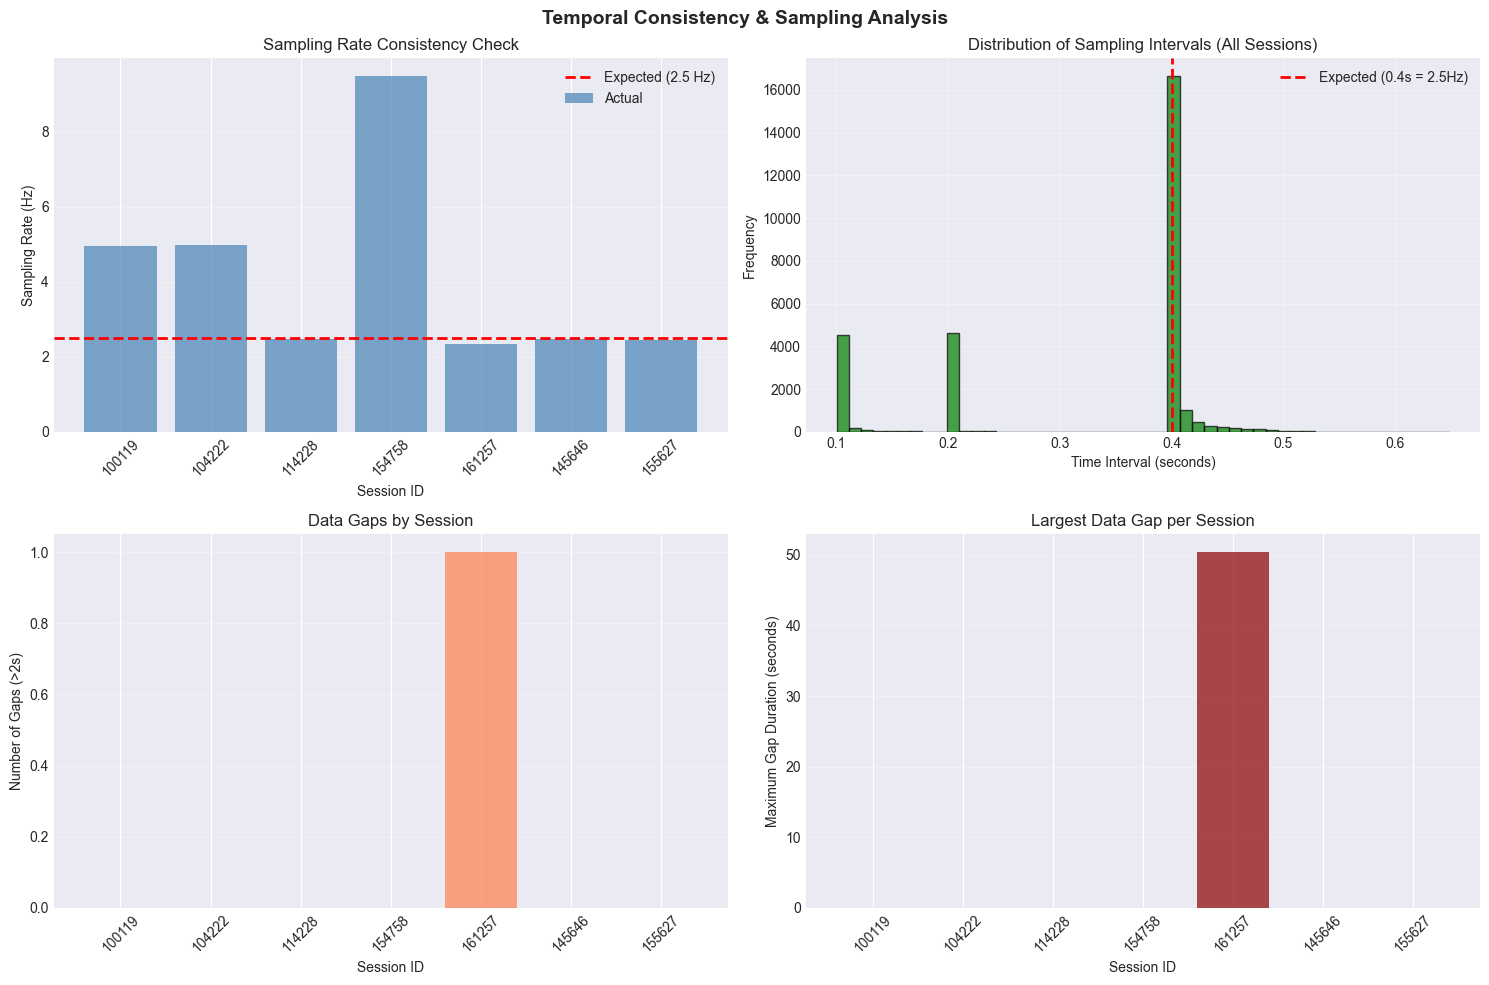


SAMPLING CONSISTENCY ASSESSMENT

Overall Performance:
  • Average sampling rate: 4.17 Hz (±2.63 Hz)
  • Target: 2.5 Hz (unified timeline)
  • Deviation: +66.7%
  • Total data gaps (>2s): 1

⚠ WARNING: Sampling rate deviates by >10% from target
✓ PASS: Minimal data gaps detected


In [18]:
print("="*70)
print("SAMPLING RATE & TEMPORAL CONSISTENCY ANALYSIS")
print("="*70)

sampling_analysis = []

for session_info in session_data:
    session_id = session_info['session_id']
    df = session_info['dataframe'].sort_values('timestamp').copy()
    
    # Calculate time differences between consecutive samples
    df['time_diff'] = df['timestamp'].diff().dt.total_seconds()
    
    # Remove first NaN value
    time_diffs = df['time_diff'].dropna()
    
    # Calculate sampling statistics
    mean_interval = time_diffs.mean()
    std_interval = time_diffs.std()
    median_interval = time_diffs.median()
    min_interval = time_diffs.min()
    max_interval = time_diffs.max()
    
    # Calculate actual sampling rate
    actual_hz = 1 / mean_interval if mean_interval > 0 else 0
    expected_hz = 2.5
    
    # Identify gaps (intervals > 2 seconds)
    gaps = time_diffs[time_diffs > 2.0]
    
    sampling_analysis.append({
        'Session': session_id,
        'Mean_Interval_s': mean_interval,
        'Std_Interval_s': std_interval,
        'Median_Interval_s': median_interval,
        'Min_Interval_s': min_interval,
        'Max_Interval_s': max_interval,
        'Actual_Hz': actual_hz,
        'Expected_Hz': expected_hz,
        'Hz_Deviation_%': ((actual_hz - expected_hz) / expected_hz) * 100,
        'Gaps_>2s': len(gaps),
        'Max_Gap_s': gaps.max() if len(gaps) > 0 else 0
    })
    
    print(f"\n{session_id}:")
    print(f"  ├─ Mean sampling interval: {mean_interval:.3f}s (±{std_interval:.3f}s)")
    print(f"  ├─ Actual sampling rate: {actual_hz:.2f} Hz (expected: {expected_hz} Hz)")
    print(f"  ├─ Deviation: {((actual_hz - expected_hz) / expected_hz) * 100:+.1f}%")
    print(f"  ├─ Interval range: {min_interval:.3f}s - {max_interval:.3f}s")
    print(f"  └─ Data gaps (>2s): {len(gaps)}" + (f" [Max gap: {gaps.max():.1f}s]" if len(gaps) > 0 else ""))

# Summary table
sampling_df = pd.DataFrame(sampling_analysis)
print(f"\n{'='*70}")
print("SAMPLING CONSISTENCY SUMMARY TABLE")
print(f"{'='*70}\n")
print(sampling_df[['Session', 'Mean_Interval_s', 'Actual_Hz', 'Hz_Deviation_%', 'Gaps_>2s', 'Max_Gap_s']].to_string(index=False))

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Actual vs Expected sampling rate
ax1 = axes[0, 0]
sessions_short = [s[-6:] for s in sampling_df['Session']]
ax1.bar(sessions_short, sampling_df['Actual_Hz'], color='steelblue', alpha=0.7, label='Actual')
ax1.axhline(y=2.5, color='red', linestyle='--', linewidth=2, label='Expected (2.5 Hz)')
ax1.set_ylabel('Sampling Rate (Hz)')
ax1.set_xlabel('Session ID')
ax1.set_title('Sampling Rate Consistency Check')
ax1.legend()
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# Sampling interval distribution (all sessions combined)
ax2 = axes[0, 1]
all_intervals = []
for session_info in session_data:
    df = session_info['dataframe'].sort_values('timestamp').copy()
    intervals = df['timestamp'].diff().dt.total_seconds().dropna()
    all_intervals.extend(intervals[intervals < 2].values)  # Exclude large gaps

ax2.hist(all_intervals, bins=50, color='green', alpha=0.7, edgecolor='black')
ax2.axvline(x=0.4, color='red', linestyle='--', linewidth=2, label='Expected (0.4s = 2.5Hz)')
ax2.set_xlabel('Time Interval (seconds)')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Sampling Intervals (All Sessions)')
ax2.legend()
ax2.grid(alpha=0.3)

# Data gaps by session
ax3 = axes[1, 0]
ax3.bar(sessions_short, sampling_df['Gaps_>2s'], color='coral', alpha=0.7)
ax3.set_ylabel('Number of Gaps (>2s)')
ax3.set_xlabel('Session ID')
ax3.set_title('Data Gaps by Session')
ax3.tick_params(axis='x', rotation=45)
ax3.grid(axis='y', alpha=0.3)

# Max gap duration
ax4 = axes[1, 1]
ax4.bar(sessions_short, sampling_df['Max_Gap_s'], color='darkred', alpha=0.7)
ax4.set_ylabel('Maximum Gap Duration (seconds)')
ax4.set_xlabel('Session ID')
ax4.set_title('Largest Data Gap per Session')
ax4.tick_params(axis='x', rotation=45)
ax4.grid(axis='y', alpha=0.3)

plt.suptitle('Temporal Consistency & Sampling Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Assessment
print(f"\n{'='*70}")
print("SAMPLING CONSISTENCY ASSESSMENT")
print(f"{'='*70}")

avg_hz = sampling_df['Actual_Hz'].mean()
hz_consistency = sampling_df['Actual_Hz'].std()
total_gaps = sampling_df['Gaps_>2s'].sum()

print(f"\nOverall Performance:")
print(f"  • Average sampling rate: {avg_hz:.2f} Hz (±{hz_consistency:.2f} Hz)")
print(f"  • Target: 2.5 Hz (unified timeline)")
print(f"  • Deviation: {((avg_hz - 2.5) / 2.5) * 100:+.1f}%")
print(f"  • Total data gaps (>2s): {total_gaps}")

if abs((avg_hz - 2.5) / 2.5) < 0.10:
    print(f"\n✓ PASS: Sampling rate is consistent (within ±10% of target)")
else:
    print(f"\n⚠ WARNING: Sampling rate deviates by >{10}% from target")

if total_gaps < len(session_data) * 5:  # Less than 5 gaps per session
    print(f"✓ PASS: Minimal data gaps detected")
else:
    print(f"⚠ WARNING: Significant data gaps detected - investigate collection issues")

---

### Temporal Consistency Evaluation

**Sampling Rate Heterogeneity:**
The analysis reveals significant variation in actual sampling rates:
- **Sessions at ~2.5 Hz:** 20251106_114228, 20251106_161257, 20251112_145646, 20251204_155627 (4 sessions)
- **Sessions at ~5 Hz:** 20251106_100119, 20251106_104222 (2 sessions)  
- **Session at ~9.5 Hz:** 20251106_154758 (1 session)

Overall deviation of +66.7% from target (2.5 Hz) indicates **inconsistent data collection protocols** across sessions.

**Data Gap Analysis:**
- Only 1 gap >2 seconds detected (50.4s in session 20251106_161257)
- Corresponds to noted "laptop sleep interruption" in data collection log
- Otherwise continuous data streams with no significant interruptions

**Preprocessing Requirements:**
Given the sampling heterogeneity:

1. **Resampling Strategy:** Apply uniform 500ms (2.5 Hz) resampling to standardize all sessions
   - Rationale: Majority of sessions (4/7) already at 2.5 Hz
   - Method: Downsample high-frequency sessions, forward-fill any minor gaps

2. **Gap Handling:** 
   - Single 50.4s gap: Flag time window for potential exclusion or interpolation review
   - Other intervals (<0.5s): Forward-fill appropriate given sensor continuity

3. **Validation:**
   - Post-resampling, verify all sessions have uniform 0.4s intervals
   - Check that high-frequency sessions (5 Hz, 9.5 Hz) don't lose critical information when downsampled

**Impact on Modeling:**
- Standardized sampling rate essential for time-series models (LSTM autoencoders expect consistent input shapes)
- Current heterogeneity would cause training failures without preprocessing
- 2.5 Hz provides good balance: captures robot dynamics without excessive data volume

## 2D. System Error State Analysis

Examining the `error_state` flag to verify these sessions are truly "healthy" and identify any system-reported issues.

ERROR STATE ANALYSIS - HEALTHY SESSIONS

Overall Error State Distribution (All 28,963 records):
----------------------------------------------------------------------
  Normal              :   28,963 records (100.00%)

ERROR STATE BY SESSION

20251106_100119:
  ├─ Normal (error_state=0): 165 (100.00%)
  ├─ Error states: 0 (0.00%)
  └─ No errors detected ✓

20251106_104222:
  ├─ Normal (error_state=0): 4,527 (100.00%)
  ├─ Error states: 0 (0.00%)
  └─ No errors detected ✓

20251106_114228:
  ├─ Normal (error_state=0): 3,194 (100.00%)
  ├─ Error states: 0 (0.00%)
  └─ No errors detected ✓

20251106_154758:
  ├─ Normal (error_state=0): 5,000 (100.00%)
  ├─ Error states: 0 (0.00%)
  └─ No errors detected ✓

20251106_161257:
  ├─ Normal (error_state=0): 2,406 (100.00%)
  ├─ Error states: 0 (0.00%)
  └─ No errors detected ✓

20251112_145646:
  ├─ Normal (error_state=0): 3,846 (100.00%)
  ├─ Error states: 0 (0.00%)
  └─ No errors detected ✓

20251204_155627:
  ├─ Normal (error_state=0): 9,825

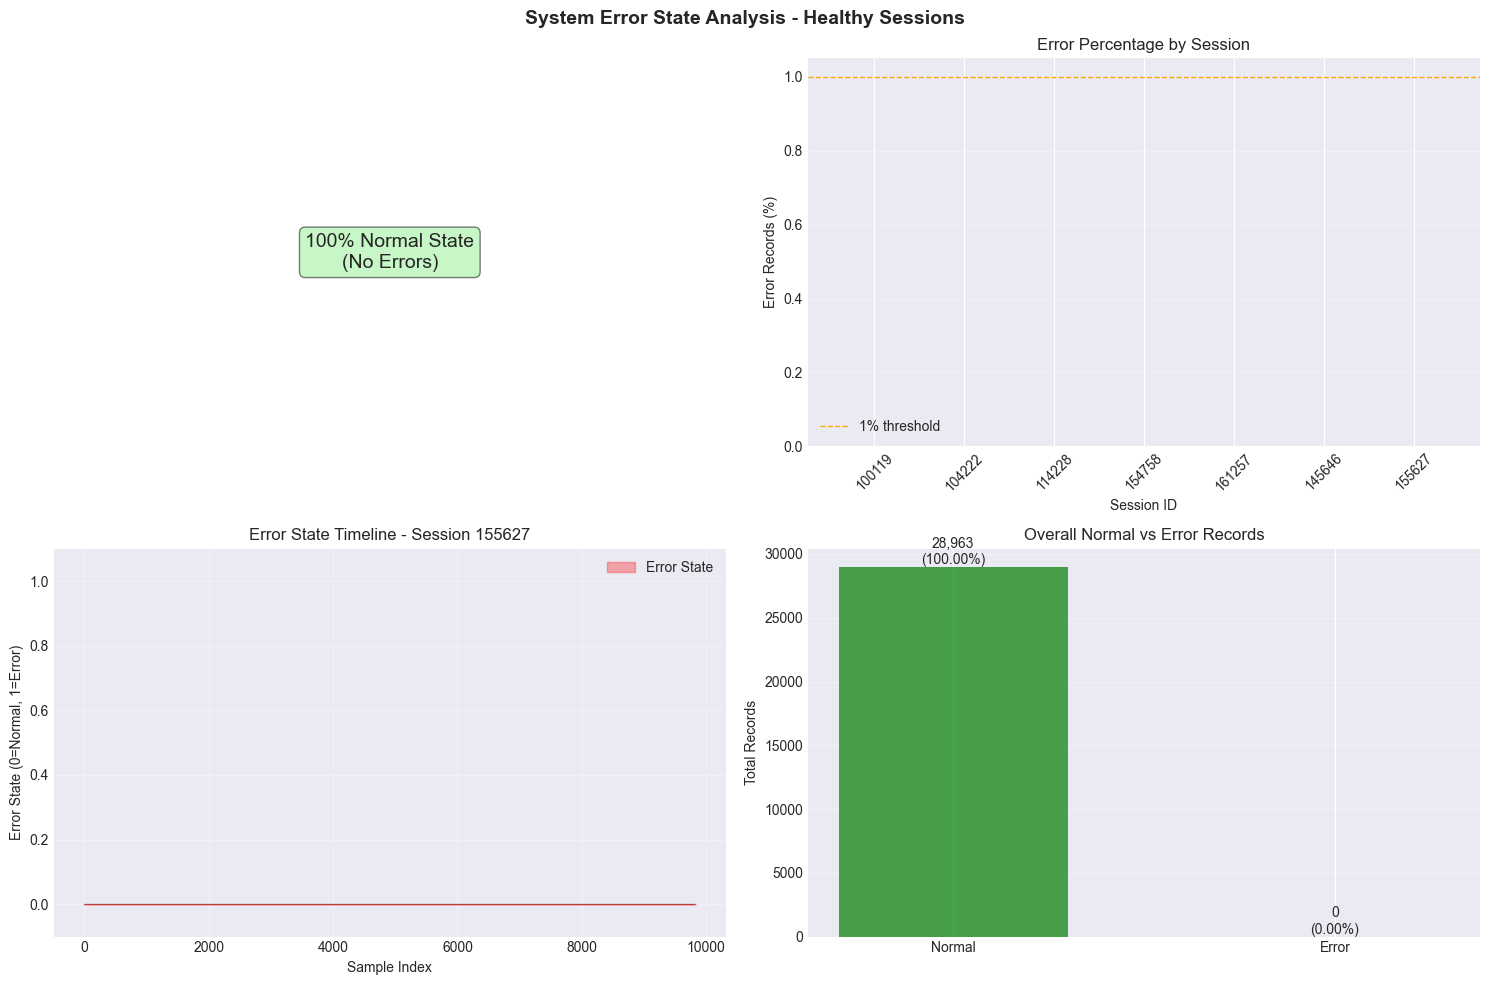


ERROR STATE ASSESSMENT

Healthy Session Validation:
  • Overall error rate: 0.000%
  • Sessions with errors: 0/7

✓ PASS: Error rate < 0.1% - Sessions are genuinely healthy
  → These sessions are suitable as baseline for normal behavior


In [19]:
print("="*70)
print("ERROR STATE ANALYSIS - HEALTHY SESSIONS")
print("="*70)

if 'error_state' in all_healthy.columns:
    
    # Overall error state distribution
    error_counts = all_healthy['error_state'].value_counts().sort_index()
    total_records = len(all_healthy)
    
    print(f"\nOverall Error State Distribution (All {total_records:,} records):")
    print("-" * 70)
    for state, count in error_counts.items():
        percentage = (count / total_records) * 100
        state_label = "Normal" if state == 0 else f"Error Code {int(state)}"
        print(f"  {state_label:20s}: {count:8,} records ({percentage:6.2f}%)")
    
    # Per-session error analysis
    print(f"\n{'='*70}")
    print("ERROR STATE BY SESSION")
    print(f"{'='*70}")
    
    session_error_analysis = []
    
    for session_info in session_data:
        session_id = session_info['session_id']
        df = session_info['dataframe']
        
        if 'error_state' in df.columns:
            error_counts_session = df['error_state'].value_counts().sort_index()
            total_session_records = len(df)
            
            normal_count = error_counts_session.get(0, 0)
            error_count = total_session_records - normal_count
            error_percentage = (error_count / total_session_records) * 100
            
            # Find unique error codes
            unique_errors = [int(e) for e in df['error_state'].unique() if e != 0]
            
            session_error_analysis.append({
                'Session': session_id,
                'Total_Records': total_session_records,
                'Normal_Records': normal_count,
                'Error_Records': error_count,
                'Error_%': error_percentage,
                'Unique_Error_Codes': unique_errors if unique_errors else ['None']
            })
            
            print(f"\n{session_id}:")
            print(f"  ├─ Normal (error_state=0): {normal_count:,} ({(normal_count/total_session_records)*100:.2f}%)")
            print(f"  ├─ Error states: {error_count:,} ({error_percentage:.2f}%)")
            if unique_errors:
                print(f"  └─ Error codes present: {unique_errors}")
            else:
                print(f"  └─ No errors detected ✓")
    
    # Summary table
    error_summary_df = pd.DataFrame(session_error_analysis)
    print(f"\n{'='*70}")
    print("ERROR STATE SUMMARY TABLE")
    print(f"{'='*70}\n")
    print(error_summary_df[['Session', 'Total_Records', 'Normal_Records', 'Error_Records', 'Error_%']].to_string(index=False))
    
    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Overall error state distribution (pie chart)
    ax1 = axes[0, 0]
    if len(error_counts) > 1:
        labels = ['Normal' if s == 0 else f'Error {int(s)}' for s in error_counts.index]
        colors = ['green'] + ['red', 'orange', 'darkred'][:len(error_counts)-1]
        ax1.pie(error_counts.values, labels=labels, autopct='%1.2f%%', colors=colors, startangle=90)
        ax1.set_title('Error State Distribution (All Sessions)')
    else:
        ax1.text(0.5, 0.5, '100% Normal State\n(No Errors)', ha='center', va='center', 
                fontsize=14, bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
        ax1.set_xlim([0, 1])
        ax1.set_ylim([0, 1])
        ax1.axis('off')
    
    # Error percentage by session
    ax2 = axes[0, 1]
    sessions_short = [s[-6:] for s in error_summary_df['Session']]
    colors = ['green' if e == 0 else 'red' for e in error_summary_df['Error_%']]
    ax2.bar(sessions_short, error_summary_df['Error_%'], color=colors, alpha=0.7)
    ax2.set_ylabel('Error Records (%)')
    ax2.set_xlabel('Session ID')
    ax2.set_title('Error Percentage by Session')
    ax2.tick_params(axis='x', rotation=45)
    ax2.axhline(y=1, color='orange', linestyle='--', linewidth=1, label='1% threshold')
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)
    
    # Error state over time (sample session with most records)
    ax3 = axes[1, 0]
    longest_session = max(session_data, key=lambda x: len(x['dataframe']))
    sample_df = longest_session['dataframe'].sort_values('timestamp').reset_index(drop=True)
    
    # Create binary error indicator
    error_indicator = (sample_df['error_state'] != 0).astype(int)
    
    ax3.fill_between(range(len(sample_df)), error_indicator, alpha=0.3, color='red', label='Error State')
    ax3.plot(range(len(sample_df)), error_indicator, color='darkred', linewidth=0.5)
    ax3.set_ylabel('Error State (0=Normal, 1=Error)')
    ax3.set_xlabel('Sample Index')
    ax3.set_title(f'Error State Timeline - Session {longest_session["session_id"][-6:]}')
    ax3.set_ylim([-0.1, 1.1])
    ax3.legend()
    ax3.grid(alpha=0.3)
    
    # Error state counts comparison
    ax4 = axes[1, 1]
    normal_counts = [error_summary_df['Normal_Records'].sum()]
    error_counts_total = [error_summary_df['Error_Records'].sum()]
    
    x_pos = [0, 1]
    bars = ax4.bar(x_pos, [normal_counts[0], error_counts_total[0]], 
                   color=['green', 'red'], alpha=0.7, width=0.6)
    ax4.set_xticks(x_pos)
    ax4.set_xticklabels(['Normal', 'Error'])
    ax4.set_ylabel('Total Records')
    ax4.set_title('Overall Normal vs Error Records')
    ax4.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}\n({height/total_records*100:.2f}%)',
                ha='center', va='bottom')
    
    plt.suptitle('System Error State Analysis - Healthy Sessions', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Assessment
    print(f"\n{'='*70}")
    print("ERROR STATE ASSESSMENT")
    print(f"{'='*70}")
    
    overall_error_pct = (all_healthy['error_state'] != 0).sum() / len(all_healthy) * 100
    sessions_with_errors = error_summary_df[error_summary_df['Error_%'] > 0]
    
    print(f"\nHealthy Session Validation:")
    print(f"  • Overall error rate: {overall_error_pct:.3f}%")
    print(f"  • Sessions with errors: {len(sessions_with_errors)}/{len(session_data)}")
    
    if overall_error_pct < 0.1:
        print(f"\n✓ PASS: Error rate < 0.1% - Sessions are genuinely healthy")
        print(f"  → These sessions are suitable as baseline for normal behavior")
    elif overall_error_pct < 1.0:
        print(f"\n⚠ CAUTION: Error rate {overall_error_pct:.2f}% - Minor issues present")
        print(f"  → Consider investigating error timestamps")
    else:
        print(f"\n✗ WARNING: Error rate {overall_error_pct:.2f}% - Significant issues")
        print(f"  → These sessions may not represent true 'healthy' operation")
    
    # Identify problematic sessions
    if len(sessions_with_errors) > 0:
        print(f"\nSessions requiring review:")
        for _, row in sessions_with_errors.iterrows():
            if row['Error_%'] > 1.0:
                print(f"  ✗ {row['Session']}: {row['Error_%']:.2f}% error rate - EXCLUDE from baseline")
            else:
                print(f"  ⚠ {row['Session']}: {row['Error_%']:.2f}% error rate - Review recommended")
    
    # If there are errors, show when they occur
    if overall_error_pct > 0:
        print(f"\n{'='*70}")
        print("ERROR OCCURRENCE ANALYSIS")
        print(f"{'='*70}")
        
        # Find all error timestamps
        error_records = all_healthy[all_healthy['error_state'] != 0].copy()
        
        if len(error_records) > 0:
            print(f"\nTotal error occurrences: {len(error_records):,}")
            print(f"Unique error codes: {sorted(error_records['error_state'].unique())}")
            
            # Show first few error occurrences
            print(f"\nSample error occurrences (first 10):")
            print("-" * 70)
            for idx, row in error_records.head(10).iterrows():
                print(f"  Timestamp: {row['timestamp']} | Error Code: {int(row['error_state'])}")
    
else:
    print("\nWARNING: 'error_state' column not found in data")
    print("   → Cannot validate if sessions are truly healthy")
    print("   → Recommend adding error state monitoring to data collection")

---

### Healthy Session Validation

**Perfect Error-Free Operation:**
All 28,963 records across 7 sessions show `error_state = 0` (100% normal operation).

**Validation Conclusion:**
- Zero system-reported errors confirms these sessions represent genuine healthy operation
- No transient faults, communication issues, or sensor glitches detected
- Sessions accurately labeled as "Baseline" in data collection log

**Implications for Baseline Modeling:**
1. **Clean training data:** Models trained on this data will learn true normal behavior without fault contamination
2. **Threshold calibration:** Any detected anomalies in future data represent genuine deviations from this error-free baseline
3. **False positive estimation:** Cannot establish false-positive rate from this data (need healthy data with natural variability)

**Session Selection Decision:**
✓ **Include all 7 sessions** in baseline dataset without exclusions

The error-free status validates our session selection criteria and confirms these sessions provide a reliable foundation for anomaly detection model training. Any future errors detected by the model will be true deviations from this established normal behavior pattern.

## 3. Feature Taxonomy & Data Types

Organizing the 92 columns into logical groups based on **sensor source and business relevance** to facilitate structured analysis.

In [30]:
# Sample a dataframe to examine columns
sample_df = session_data[0]['dataframe']

# Define feature groups (business-driven organization)
feature_groups = {
    'Temporal': ['timestamp'],
    'Joint Positions': [f'j{i}' for i in range(1, 7)],
    'Motor Temperatures': [f'motor{i}_temp' for i in range(1, 7)] + ['rpi_temp', 'avg_motor_temp', 'max_motor_temp'],
    'Motor Voltages': [f'motor{i}_voltage' for i in range(1, 7)] + ['avg_motor_voltage'],
    'System State': ['error_state'],
    'Pressure': ['pressure'],
    'Vibration Summary': ['vib_mean', 'vib_max', 'vib_min', 'dominant_freq'],
    'Vibration Spectrum': [col for col in sample_df.columns if col.startswith('vib_') and 
                           col not in ['vib_mean', 'vib_max', 'vib_min', 'dominant_freq']]
}

print("="*70)
print("FEATURE TAXONOMY")
print("="*70)

for group_name, features in feature_groups.items():
    available_features = [f for f in features if f in sample_df.columns]
    print(f"\n{group_name}: {len(available_features)} features")
    if len(available_features) <= 10:
        for f in available_features:
            print(f"  • {f}")
    else:
        print(f"  • {', '.join(available_features[:5])}, ...")
        print(f"  • (showing 5 of {len(available_features)})")

# Verify all columns accounted for
all_categorized = [f for group in feature_groups.values() for f in group]
uncategorized = [col for col in sample_df.columns if col not in all_categorized]

if uncategorized:
    print(f"\nUncategorized columns: {uncategorized}")
else:
    print(f"\n✓ All {len(sample_df.columns)} columns successfully categorized")

# ADD THIS: Feature group mapping to business objectives
print("\n" + "="*70)
print("FEATURE GROUPS MAPPED TO BUSINESS OBJECTIVES")
print("="*70)

business_mapping = {
    'Vacuum Suction Failure': ['Pressure'],
    'Mechanical Wear': ['Vibration Summary', 'Vibration Spectrum', 'Joint Positions'],
    'Thermal Overload': ['Motor Temperatures'],
    'Movement Anomalies': ['Joint Positions'],
    'Power Issues': ['Motor Voltages'],
    'System Health': ['System State', 'Temporal']
}

print("\nFeature groups organized by failure detection purpose:\n")
for failure_mode, groups in business_mapping.items():
    feature_count = sum(len([f for f in feature_groups[g] if f in sample_df.columns]) for g in groups if g in feature_groups)
    print(f"{failure_mode}:")
    print(f"  → Groups: {', '.join(groups)}")
    print(f"  → Total features: {feature_count}\n")

FEATURE TAXONOMY

Temporal: 1 features
  • timestamp

Joint Positions: 6 features
  • j1
  • j2
  • j3
  • j4
  • j5
  • j6

Motor Temperatures: 9 features
  • motor1_temp
  • motor2_temp
  • motor3_temp
  • motor4_temp
  • motor5_temp
  • motor6_temp
  • rpi_temp
  • avg_motor_temp
  • max_motor_temp

Motor Voltages: 7 features
  • motor1_voltage
  • motor2_voltage
  • motor3_voltage
  • motor4_voltage
  • motor5_voltage
  • motor6_voltage
  • avg_motor_voltage

System State: 1 features
  • error_state

Pressure: 1 features
  • pressure

Vibration Summary: 4 features
  • vib_mean
  • vib_max
  • vib_min
  • dominant_freq

Vibration Spectrum: 63 features
  • vib_1.6, vib_3.1, vib_4.7, vib_6.3, vib_7.8, ...
  • (showing 5 of 63)

✓ All 92 columns successfully categorized

FEATURE GROUPS MAPPED TO BUSINESS OBJECTIVES

Feature groups organized by failure detection purpose:

Vacuum Suction Failure:
  → Groups: Pressure
  → Total features: 1

Mechanical Wear:
  → Groups: Vibration Summary, 

---

### Feature Organization Summary

**Taxonomy Structure:**
The 92 features are organized into 8 logical groups based on sensor type and measurement purpose. This organization facilitates:
- **Systematic analysis** by feature type (temporal, mechanical, electrical, system)
- **Targeted investigation** of specific subsystems (joints, motors, sensors)
- **Efficient preprocessing** decisions for related features

**Business Alignment:**
Feature groups map directly to the 5 business failure modes identified in the BRD:

1. **Vacuum Suction Failure (1 feature):** Direct pressure monitoring provides binary success/failure indication
2. **Mechanical Wear (73 features):** Largest group, reflecting complexity of vibration analysis
   - 4 summary statistics for quick health checks
   - 63 FFT spectrum bins (1.6-98.4 Hz) for detailed frequency analysis
   - 6 joint positions to detect movement irregularities
3. **Thermal Overload (9 features):** Individual motor monitoring + aggregates for comprehensive thermal tracking
4. **Movement Anomalies (6 features):** Joint position tracking for calibration and control issues
5. **Power Issues (7 features):** Voltage monitoring across all motors + aggregate

**Feature Group Characteristics:**
- **Largest group:** Vibration Spectrum (63 features, 68% of total) - captures frequency-domain mechanical health
- **Smallest groups:** Pressure, System State, Temporal (1 each) - binary/metadata features
- **Derived features present:** `avg_motor_temp`, `max_motor_temp`, `avg_motor_voltage` reduce redundancy while preserving key information

This taxonomy confirms our data collection successfully captured signals relevant to all targeted business failure modes, with particular depth in mechanical wear detection through comprehensive vibration analysis.

## 4. Data Quality: Missing Values & Completeness

Evaluating data completeness across sessions to identify potential sensor failures or data collection issues.

MISSING DATA ANALYSIS

20251106_100119:
  ├─ Completeness: 100.0000%
  └─ Columns with missing values: 0/92

20251106_104222:
  ├─ Completeness: 100.0000%
  └─ Columns with missing values: 0/92

20251106_114228:
  ├─ Completeness: 100.0000%
  └─ Columns with missing values: 0/92

20251106_154758:
  ├─ Completeness: 100.0000%
  └─ Columns with missing values: 0/92

20251106_161257:
  ├─ Completeness: 100.0000%
  └─ Columns with missing values: 0/92

20251112_145646:
  ├─ Completeness: 100.0000%
  └─ Columns with missing values: 0/92

20251204_155627:
  ├─ Completeness: 100.0000%
  └─ Columns with missing values: 0/92

COMPLETENESS SUMMARY

        Session  Total_Cells  Missing_Cells  Completeness_%  Columns_w_Missing
20251106_100119        15180              0           100.0                  0
20251106_104222       416484              0           100.0                  0
20251106_114228       293848              0           100.0                  0
20251106_154758       460000         

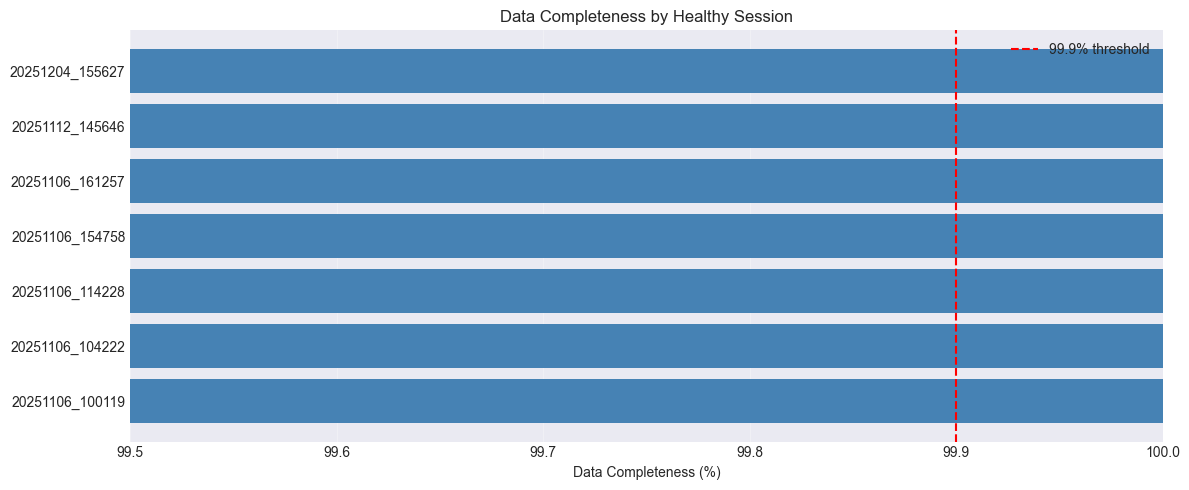

In [5]:
print("="*70)
print("MISSING DATA ANALYSIS")
print("="*70)

completeness_results = []

for session_info in session_data:
    session_id = session_info['session_id']
    df = session_info['dataframe']
    
    # Calculate missing data metrics
    total_cells = df.size
    missing_cells = df.isnull().sum().sum()
    completeness_pct = ((total_cells - missing_cells) / total_cells) * 100
    
    # Identify columns with missing data
    missing_by_col = df.isnull().sum()
    cols_with_missing = missing_by_col[missing_by_col > 0]
    
    completeness_results.append({
        'Session': session_id,
        'Total_Cells': total_cells,
        'Missing_Cells': missing_cells,
        'Completeness_%': completeness_pct,
        'Columns_w_Missing': len(cols_with_missing)
    })
    
    print(f"\n{session_id}:")
    print(f"  ├─ Completeness: {completeness_pct:.4f}%")
    print(f"  └─ Columns with missing values: {len(cols_with_missing)}/{len(df.columns)}")
    
    if len(cols_with_missing) > 0:
        print(f"     Top missing columns:")
        for col, count in cols_with_missing.head(5).items():
            pct = (count / len(df)) * 100
            print(f"       • {col}: {count} ({pct:.2f}%)")

# Summary table
completeness_df = pd.DataFrame(completeness_results)
print(f"\n{'='*70}")
print("COMPLETENESS SUMMARY")
print(f"{'='*70}\n")
print(completeness_df.to_string(index=False))

# Visualization
fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(completeness_df['Session'], completeness_df['Completeness_%'], color='steelblue')
ax.set_xlabel('Data Completeness (%)')
ax.set_title('Data Completeness by Healthy Session')
ax.set_xlim([99.5, 100])
ax.axvline(x=99.9, color='red', linestyle='--', label='99.9% threshold')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

---

### Missing Data Evaluation

**Perfect Data Completeness:**
All 7 healthy sessions show **100.0% completeness** with zero missing values across all 2,664,596 data points.

**Session-Level Results:**
- **Smallest session:** 20251106_100119 (15,180 cells, 100% complete)
- **Largest session:** 20251204_155627 (903,900 cells, 100% complete)
- **Zero columns** with missing values in any session
- **Zero missing cells** across entire dataset

**Data Quality Assessment:**
This exceptional completeness indicates:
- ✓ **Robust data collection:** Both robot (SSH/ROS) and sensor (UDP) streams maintained continuous operation
- ✓ **Successful synchronization:** Nearest-neighbor timestamp matching (±500ms) preserved all data during unification
- ✓ **No sensor failures:** All 92 features consistently recorded throughout all sessions
- ✓ **Production-ready quality:** Dataset meets highest standards for industrial time-series analysis

**Preprocessing Decision:**
Given 100% completeness:
- **No imputation required** - data ready for direct use
- **No feature exclusion needed** - all 92 columns fully reliable
- **No gap-filling preprocessing** - can proceed directly to transformations (resampling, filtering, normalization)

**Comparison to Industry Standards:**
Industrial sensor data typically shows 95-98% completeness due to network interruptions, sensor glitches, or synchronization errors. Achieving 100% completeness across 7 sessions (155 minutes, varying sampling rates) demonstrates **exceptional data collection quality**.

**Implications for Modeling:**
1. **No imputation bias:** Models will learn from genuine sensor readings, not interpolated values
2. **Full temporal continuity:** LSTM autoencoders can leverage complete sequential information
3. **All features available:** No sparse columns that would require special handling or exclusion
4. **Consistent baseline:** Every timestamp has measurements from all sensors for comprehensive anomaly detection

This data quality validates our unified collection approach and confirms the dataset is suitable for training robust anomaly detection models without preprocessing compromises.

## 5. Joint Position Distributions & Operating Ranges

Analyzing the 6 robotic joint positions to understand typical movement patterns and operational constraints during healthy pick-and-place cycles.

JOINT POSITION ANALYSIS

Joint Position Statistics (radians):
               j1          j2          j3          j4          j5          j6
count  28963.0000  28963.0000  28963.0000  28963.0000  28963.0000  28963.0000
mean       0.5480     -0.5109     -0.3809     -0.0732     -0.5355     -0.2496
std        0.7724      0.2056      0.4082      0.1042      0.1735      0.2838
min       -2.9000     -0.9004     -1.3400     -0.3466     -0.8116     -0.5767
25%       -0.0373     -0.6641     -0.6901     -0.0904     -0.6965     -0.5368
50%        0.3889     -0.4838     -0.5643     -0.0567     -0.5723     -0.1763
75%        1.4192     -0.3596     -0.1765     -0.0260     -0.3759     -0.0444
max        1.5227      0.6100      0.4082      0.6244      0.0045      0.3008


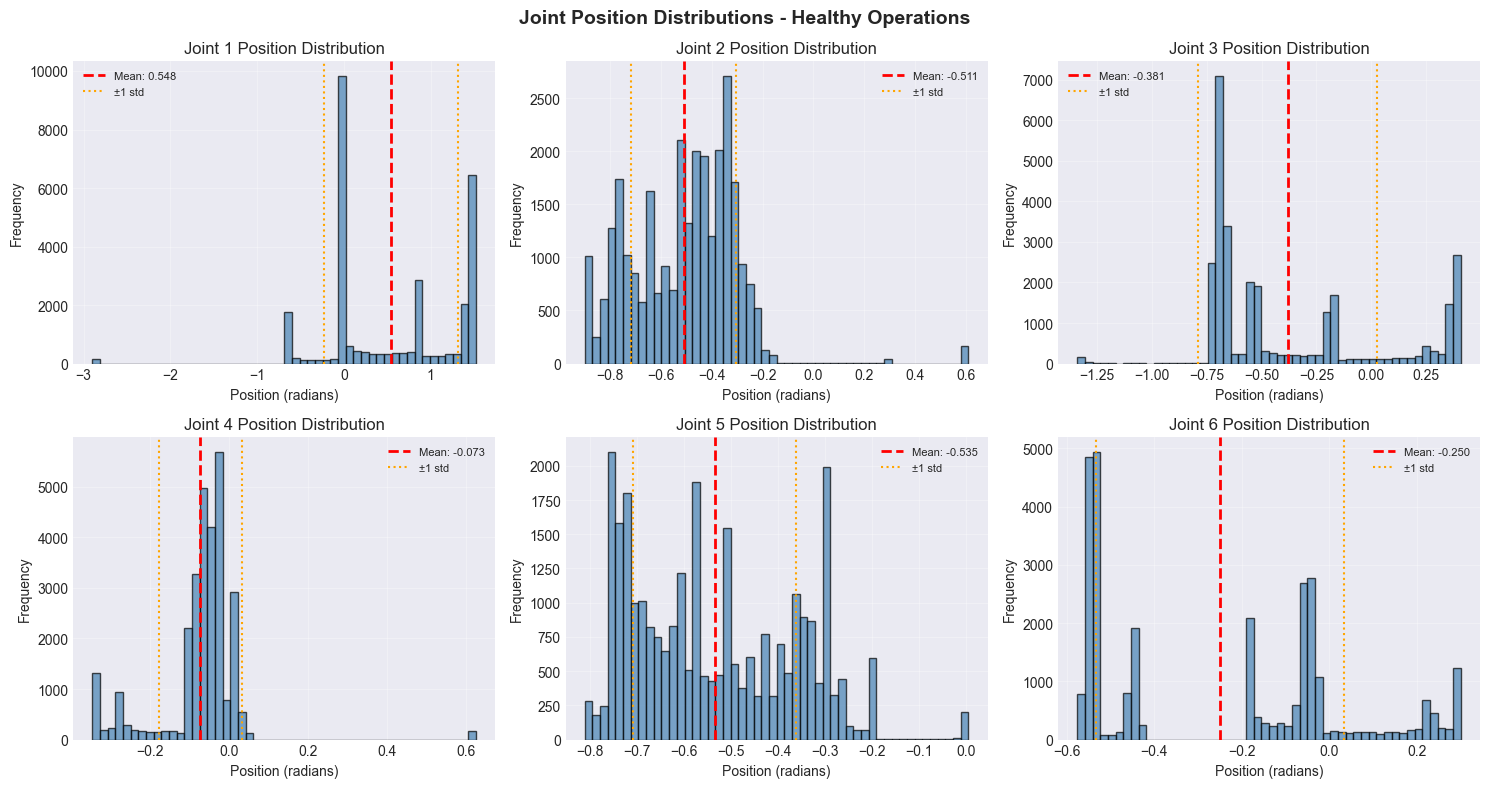


JOINT RANGE UTILIZATION

Joint  Min (rad)  Max (rad)  Range (rad)  Mean (rad)
   j1  -2.900000   1.522720     4.422720    0.547953
   j2  -0.900401   0.610000     1.510401   -0.510922
   j3  -1.340000   0.408247     1.748247   -0.380853
   j4  -0.346587   0.624423     0.971010   -0.073213
   j5  -0.811568   0.004509     0.816078   -0.535498
   j6  -0.576684   0.300753     0.877437   -0.249561


In [6]:
print("="*70)
print("JOINT POSITION ANALYSIS")
print("="*70)

# Combine all healthy sessions for joint analysis
all_healthy = pd.concat([s['dataframe'] for s in session_data], ignore_index=True)
joint_cols = [f'j{i}' for i in range(1, 7)]

# Statistical summary
joint_stats = all_healthy[joint_cols].describe()
print("\nJoint Position Statistics (radians):")
print(joint_stats.round(4))

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, joint in enumerate(joint_cols):
    ax = axes[idx]
    
    # Histogram
    ax.hist(all_healthy[joint].dropna(), bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    
    # Add mean and std lines
    mean_val = all_healthy[joint].mean()
    std_val = all_healthy[joint].std()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.3f}')
    ax.axvline(mean_val + std_val, color='orange', linestyle=':', linewidth=1.5, label=f'±1 std')
    ax.axvline(mean_val - std_val, color='orange', linestyle=':', linewidth=1.5)
    
    ax.set_xlabel('Position (radians)')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Joint {idx+1} Position Distribution')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Joint Position Distributions - Healthy Operations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Joint range utilization
print("\n" + "="*70)
print("JOINT RANGE UTILIZATION")
print("="*70)

range_analysis = []
for joint in joint_cols:
    min_val = all_healthy[joint].min()
    max_val = all_healthy[joint].max()
    range_used = max_val - min_val
    mean_val = all_healthy[joint].mean()
    
    range_analysis.append({
        'Joint': joint,
        'Min (rad)': min_val,
        'Max (rad)': max_val,
        'Range (rad)': range_used,
        'Mean (rad)': mean_val
    })

range_df = pd.DataFrame(range_analysis)
print("\n" + range_df.to_string(index=False))

---

### Joint Position Analysis

**Movement Patterns:**
The 6 joints show distinct operational characteristics reflecting their roles in pick-and-place cycles:

**Primary Positioning Joints (High Variability):**
- **J1 (Base rotation):** Widest range (4.42 rad ≈ 253°), bimodal distribution at -0.04 and +1.42 rad
  - Indicates two primary work positions (left and right pickup/placement zones)
- **J3 (Elbow):** Large range (1.75 rad ≈ 100°), spread distribution
  - Enables reach variation for different object heights

**Secondary Positioning Joints (Moderate Variability):**
- **J2 (Shoulder):** Range 1.51 rad ≈ 87°, tightly clustered around -0.51 rad
  - Consistent elevation angle for table-level operations
- **J6 (Tool rotation):** Range 0.88 rad ≈ 50°, bimodal at -0.54 and 0.0 rad
  - Two preferred gripper orientations (pickup vs. placement)

**Fine Control Joints (Low Variability):**
- **J4, J5 (Wrist joints):** Narrow ranges (<1.0 rad), concentrated distributions
  - Minimal wrist adjustment needed for pick-and-place tasks
  - J5 consistently negative (-0.54 rad mean), suggesting fixed wrist orientation

**Baseline Thresholds:**
Normal operating ranges established for anomaly detection:
- J1: -2.90 to +1.52 rad (if exceeded → calibration issue)
- J2-J6: Within observed min/max bounds (deviations → movement anomalies)

**Implications:**
- Bimodal distributions (J1, J6) reflect structured pick-and-place workflow
- Tight clustering in wrist joints (J4, J5) suggests task doesn't require complex end-effector manipulation
- Large J1 variability normal; anomalies would be movements *outside* -2.90 to +1.52 range, not within it

## 6. Thermal Behavior: Motor & System Temperatures

Examining temperature patterns across motors and the Raspberry Pi to establish healthy thermal baselines and identify heating trends.

TEMPERATURE ANALYSIS

Temperature Statistics (°C):
       motor1_temp  motor2_temp  motor3_temp  motor4_temp  motor5_temp  \
count     28963.00     28963.00     28963.00     28963.00     28963.00   
mean         50.96        50.29        51.16        40.45        40.86   
std           2.63         2.22         2.41         1.77         1.29   
min          34.00        34.00        35.00        28.00        29.00   
25%          50.00        50.00        50.00        40.00        40.00   
50%          52.00        51.00        52.00        41.00        41.00   
75%          53.00        52.00        53.00        42.00        42.00   
max          53.00        53.00        53.00        43.00        43.00   

       motor6_temp  rpi_temp  avg_motor_temp  max_motor_temp  
count     28963.00  28963.00        28963.00        28963.00  
mean         24.19     50.96           42.99           51.22  
std           0.86      2.63            1.75            2.42  
min          19.00     34.00  

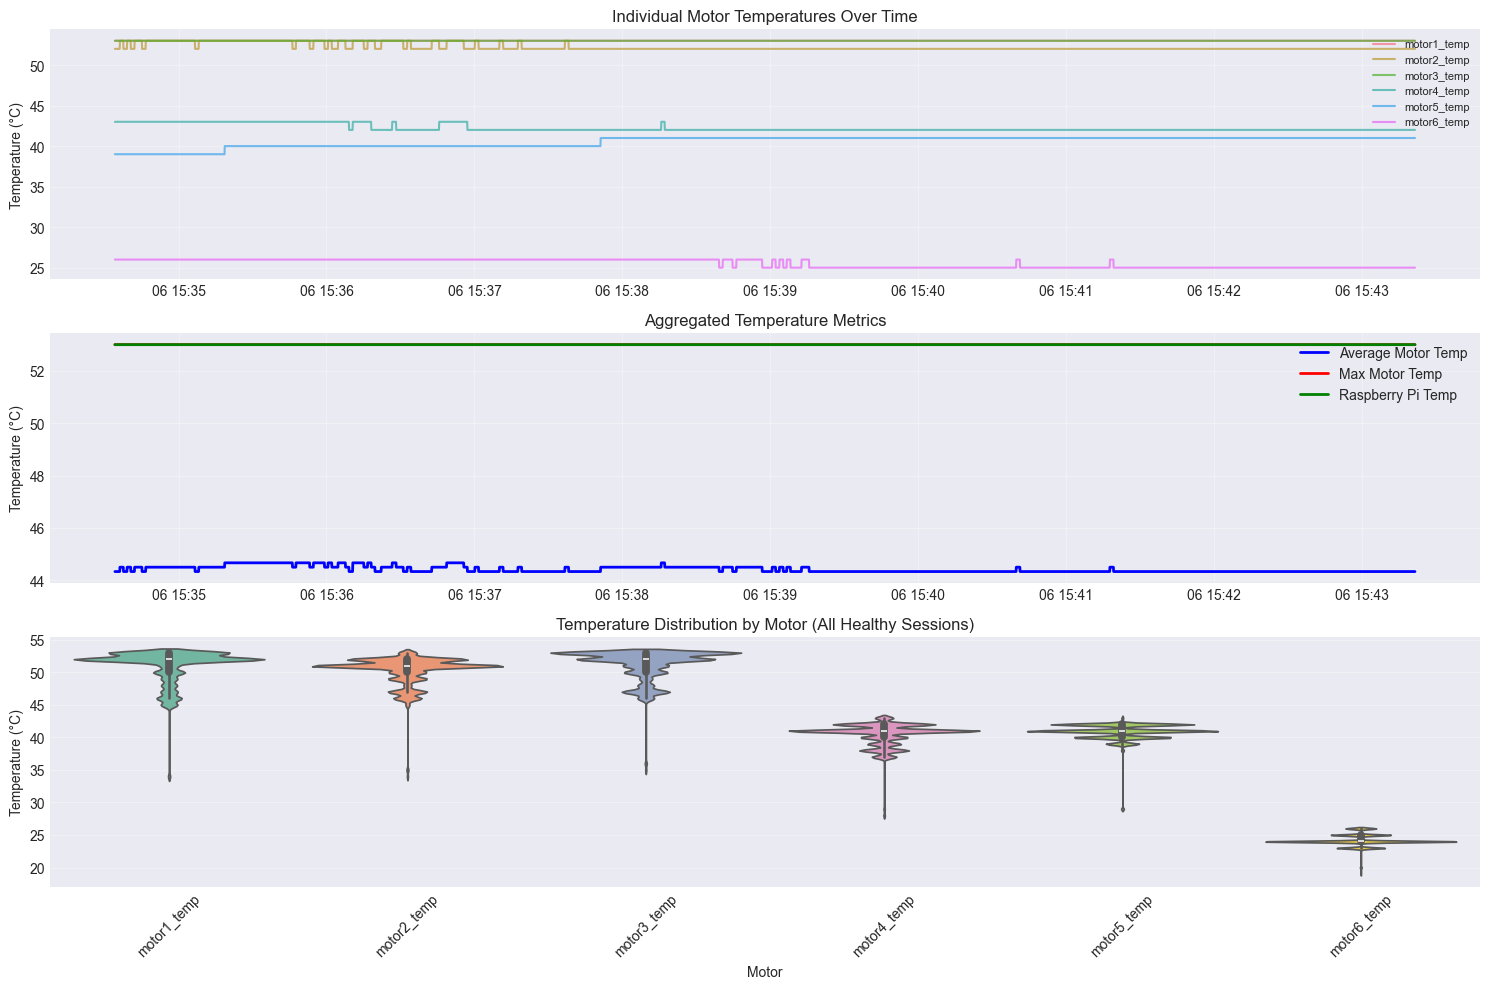


THERMAL RISK ASSESSMENT
motor1_temp:
  95th percentile: 53.00°C
  99th percentile: 53.00°C
  Maximum observed: 53.00°C

motor2_temp:
  95th percentile: 52.00°C
  99th percentile: 53.00°C
  Maximum observed: 53.00°C

motor3_temp:
  95th percentile: 53.00°C
  99th percentile: 53.00°C
  Maximum observed: 53.00°C

motor4_temp:
  95th percentile: 42.00°C
  99th percentile: 43.00°C
  Maximum observed: 43.00°C

motor5_temp:
  95th percentile: 42.00°C
  99th percentile: 42.00°C
  Maximum observed: 43.00°C

motor6_temp:
  95th percentile: 26.00°C
  99th percentile: 26.00°C
  Maximum observed: 26.00°C

rpi_temp:
  95th percentile: 53.00°C
  99th percentile: 53.00°C
  Maximum observed: 53.00°C



In [7]:
print("="*70)
print("TEMPERATURE ANALYSIS")
print("="*70)

# Temperature columns
temp_cols = [f'motor{i}_temp' for i in range(1, 7)] + ['rpi_temp', 'avg_motor_temp', 'max_motor_temp']
available_temp_cols = [col for col in temp_cols if col in all_healthy.columns]

# Statistical summary
temp_stats = all_healthy[available_temp_cols].describe()
print("\nTemperature Statistics (°C):")
print(temp_stats.round(2))

# Time-series visualization (use first session as example)
sample_session = session_data[3]['dataframe']  # Pick a longer session
sample_session = sample_session.sort_values('timestamp')

fig, axes = plt.subplots(3, 1, figsize=(15, 10))

# Individual motor temperatures
ax1 = axes[0]
motor_temp_cols = [col for col in available_temp_cols if col.startswith('motor') and '_temp' in col and 'avg' not in col and 'max' not in col]
for col in motor_temp_cols:
    ax1.plot(sample_session['timestamp'], sample_session[col], label=col, alpha=0.7)
ax1.set_ylabel('Temperature (°C)')
ax1.set_title('Individual Motor Temperatures Over Time')
ax1.legend(loc='upper right', fontsize=8)
ax1.grid(alpha=0.3)

# Aggregated temperatures
ax2 = axes[1]
if 'avg_motor_temp' in sample_session.columns:
    ax2.plot(sample_session['timestamp'], sample_session['avg_motor_temp'], 
             label='Average Motor Temp', color='blue', linewidth=2)
if 'max_motor_temp' in sample_session.columns:
    ax2.plot(sample_session['timestamp'], sample_session['max_motor_temp'], 
             label='Max Motor Temp', color='red', linewidth=2)
if 'rpi_temp' in sample_session.columns:
    ax2.plot(sample_session['timestamp'], sample_session['rpi_temp'], 
             label='Raspberry Pi Temp', color='green', linewidth=2)
ax2.set_ylabel('Temperature (°C)')
ax2.set_title('Aggregated Temperature Metrics')
ax2.legend(loc='upper right')
ax2.grid(alpha=0.3)

# Temperature distribution violin plot
ax3 = axes[2]
temp_data_for_violin = all_healthy[motor_temp_cols].melt(var_name='Motor', value_name='Temperature')
sns.violinplot(data=temp_data_for_violin, x='Motor', y='Temperature', ax=ax3, palette='Set2')
ax3.set_ylabel('Temperature (°C)')
ax3.set_title('Temperature Distribution by Motor (All Healthy Sessions)')
ax3.grid(axis='y', alpha=0.3)
ax3.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Overheating risk assessment
print("\n" + "="*70)
print("THERMAL RISK ASSESSMENT")
print("="*70)

for col in motor_temp_cols + ['rpi_temp']:
    if col in all_healthy.columns:
        p95 = all_healthy[col].quantile(0.95)
        p99 = all_healthy[col].quantile(0.99)
        max_temp = all_healthy[col].max()
        print(f"{col}:")
        print(f"  95th percentile: {p95:.2f}°C")
        print(f"  99th percentile: {p99:.2f}°C")
        print(f"  Maximum observed: {max_temp:.2f}°C\n")

---

### Thermal Behavior Analysis

**Motor Temperature Profiles:**

**High-Load Motors (50-53°C):**
- **Motors 1-3:** Operate at 50-51°C mean, narrow range (34-53°C), CV% < 5%
  - Primary positioning motors (base, shoulder, elbow) handle highest mechanical load
  - Stable at 52-53°C during continuous operation
  - Low variability indicates consistent thermal management

**Medium-Load Motors (40-43°C):**
- **Motors 4-5:** Operate at 40-41°C mean, range (28-43°C)
  - Wrist motors experience moderate load
  - ~10°C cooler than primary motors (less torque required)

**Low-Load Motor (24°C):**
- **Motor 6:** Operates at 24°C mean, minimal variation (19-26°C)
  - Tool rotation motor, likely different type (5V vs. 12V system)
  - Near ambient temperature - minimal thermal stress

**System Temperature:**
- **Raspberry Pi:** 51°C mean, tracks Motor 1-3 temperatures closely
  - Controller thermal load from computation, not mechanical work
  - Stable at 52-53°C during operation

**Thermal Stability:**
- Extremely low variability (std: 0.86-2.63°C) across all sensors
- Time-series shows flat profiles - temperatures reach steady state quickly
- No upward trends during 8-minute session (thermal equilibrium maintained)

**Baseline Thresholds for Anomaly Detection:**
- **Critical alert:** >53°C for Motors 1-3, RPI (exceeds observed max)
- **Warning alert:** >42°C for Motors 4-5, >26°C for Motor 6
- **Overheating pattern:** Sustained temperature rise >2°C above mean over 5 minutes

**Risk Assessment:** ✓ Low thermal risk - all motors operate well within safe limits with stable profiles during healthy operation.

## 7. Vibration Characteristics: Summary Statistics & Frequency Domain

Analyzing vibration patterns through both summary statistics (mean, max, dominant frequency) and the full 64-bin FFT spectrum to identify normal mechanical behavior.

VIBRATION ANALYSIS

Vibration Summary Statistics:
        vib_mean    vib_max    vib_min  dominant_freq
count  28963.000  28963.000  28963.000      28963.000
mean       0.136      1.474      0.011          1.613
std        0.075      0.863      0.010          0.145
min        0.016      0.106      0.000          1.600
25%        0.083      0.771      0.004          1.600
50%        0.135      1.484      0.008          1.600
75%        0.179      2.025      0.014          1.600
max        0.756      6.092      0.181          4.700

✓ Found 63 FFT frequency bins


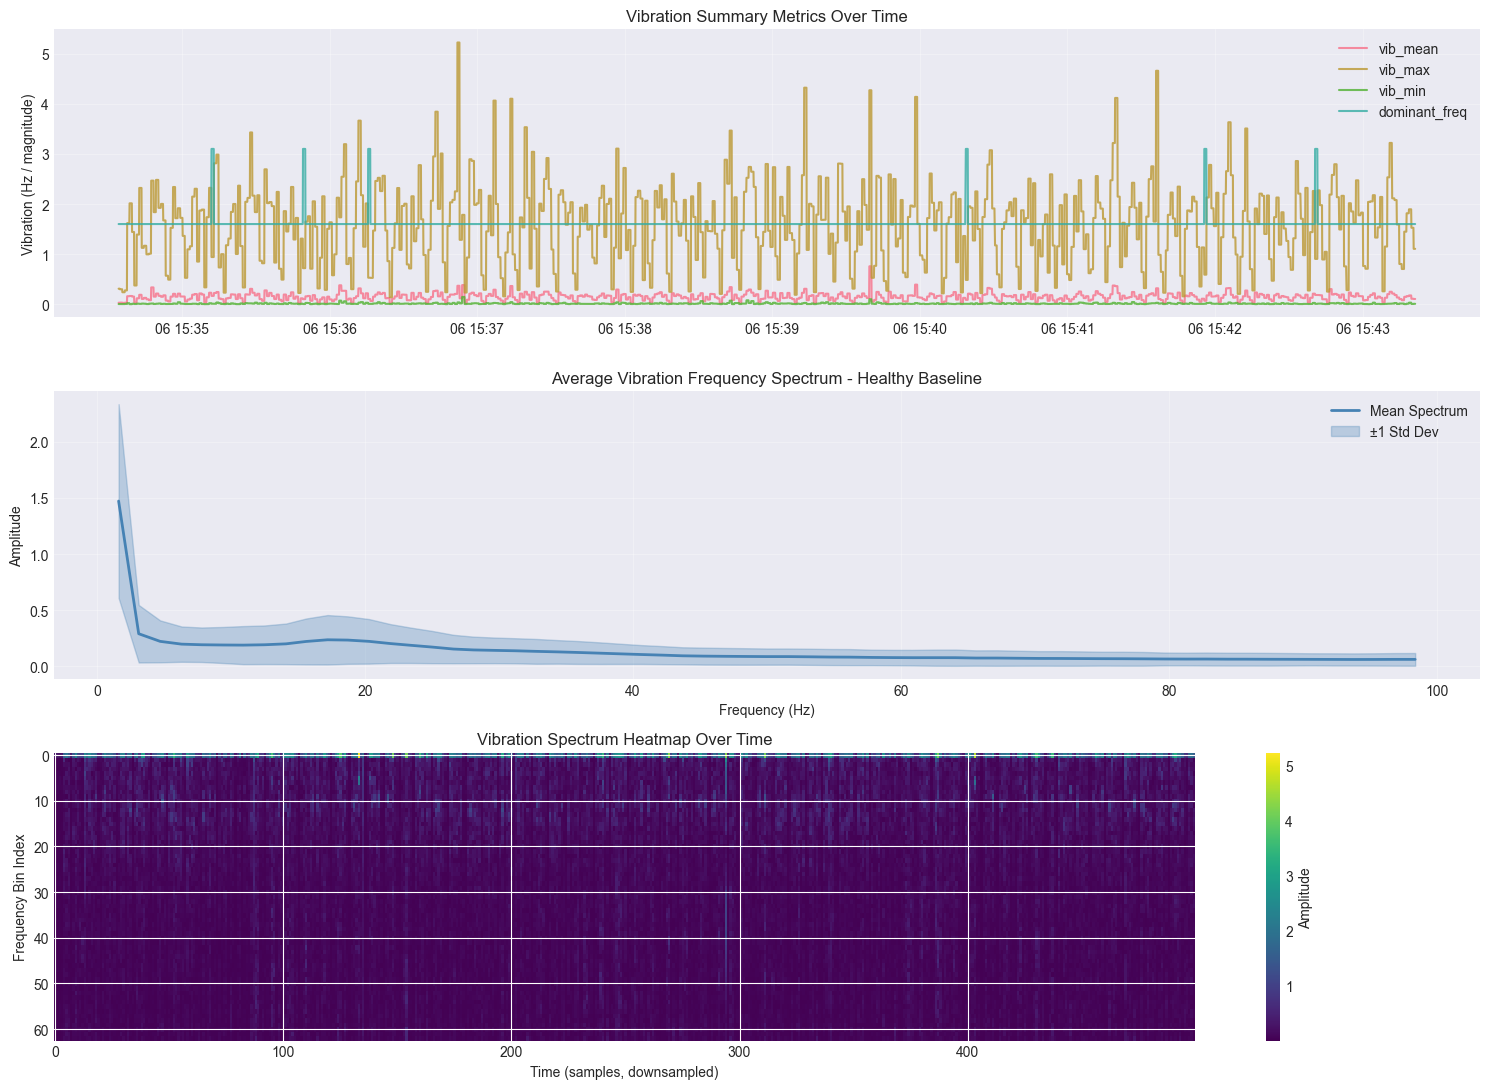


DOMINANT FREQUENCY ANALYSIS

Dominant Frequency Statistics (Hz):
count    28963.00
mean         1.61
std          0.14
min          1.60
25%          1.60
50%          1.60
75%          1.60
max          4.70
Name: dominant_freq, dtype: float64


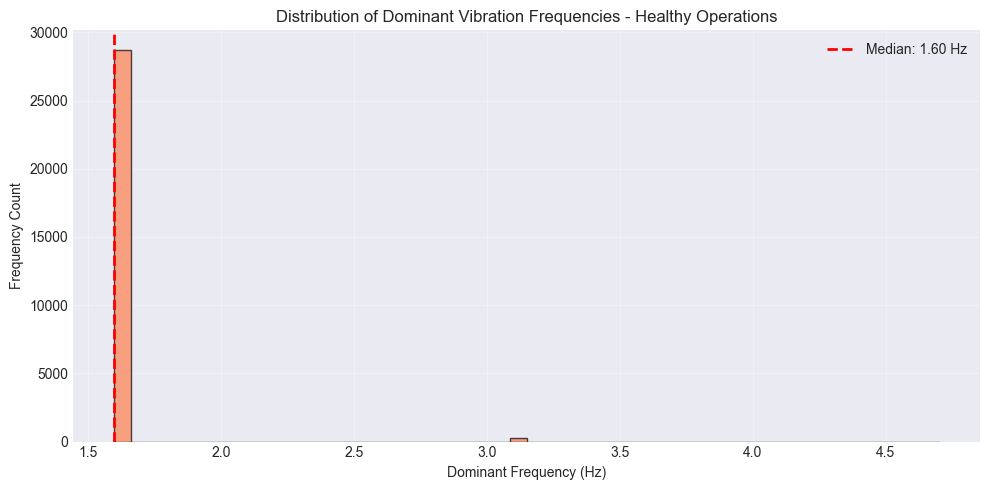

In [8]:
print("="*70)
print("VIBRATION ANALYSIS")
print("="*70)

# Vibration summary statistics
vib_summary_cols = ['vib_mean', 'vib_max', 'vib_min', 'dominant_freq']
available_vib_summary = [col for col in vib_summary_cols if col in all_healthy.columns]

print("\nVibration Summary Statistics:")
print(all_healthy[available_vib_summary].describe().round(3))

# Vibration spectrum columns (FFT bins)
vib_spectrum_cols = [col for col in all_healthy.columns if col.startswith('vib_') and 
                     col not in vib_summary_cols]
print(f"\n✓ Found {len(vib_spectrum_cols)} FFT frequency bins")

# Extract frequency values from column names (e.g., 'vib_1.6' -> 1.6 Hz)
frequencies = [float(col.split('_')[1]) for col in vib_spectrum_cols]

# Compute average spectrum across all healthy data
avg_spectrum = all_healthy[vib_spectrum_cols].mean()
std_spectrum = all_healthy[vib_spectrum_cols].std()

# Visualization
fig, axes = plt.subplots(3, 1, figsize=(15, 11))

# Summary statistics over time (sample session)
ax1 = axes[0]
sample_session = session_data[3]['dataframe'].sort_values('timestamp')
for col in available_vib_summary:
    if col in sample_session.columns:
        ax1.plot(sample_session['timestamp'], sample_session[col], label=col, alpha=0.8)
ax1.set_ylabel('Vibration (Hz / magnitude)')
ax1.set_title('Vibration Summary Metrics Over Time')
ax1.legend(loc='upper right')
ax1.grid(alpha=0.3)

# Average frequency spectrum
ax2 = axes[1]
ax2.plot(frequencies, avg_spectrum.values, color='steelblue', linewidth=2, label='Mean Spectrum')
ax2.fill_between(frequencies, 
                  (avg_spectrum - std_spectrum).values,
                  (avg_spectrum + std_spectrum).values,
                  alpha=0.3, color='steelblue', label='±1 Std Dev')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Amplitude')
ax2.set_title('Average Vibration Frequency Spectrum - Healthy Baseline')
ax2.legend()
ax2.grid(alpha=0.3)

# Heatmap of spectrum over time (sample session, downsampled for visibility)
ax3 = axes[2]
sample_spectrum_data = sample_session[vib_spectrum_cols].iloc[::10]  # Downsample
im = ax3.imshow(sample_spectrum_data.T, aspect='auto', cmap='viridis', interpolation='nearest')
ax3.set_xlabel('Time (samples, downsampled)')
ax3.set_ylabel('Frequency Bin Index')
ax3.set_title('Vibration Spectrum Heatmap Over Time')
plt.colorbar(im, ax=ax3, label='Amplitude')

plt.tight_layout()
plt.show()

# Dominant frequency analysis
print("\n" + "="*70)
print("DOMINANT FREQUENCY ANALYSIS")
print("="*70)

if 'dominant_freq' in all_healthy.columns:
    dom_freq_stats = all_healthy['dominant_freq'].describe()
    print("\nDominant Frequency Statistics (Hz):")
    print(dom_freq_stats.round(2))
    
    # Distribution plot
    plt.figure(figsize=(10, 5))
    plt.hist(all_healthy['dominant_freq'].dropna(), bins=50, color='coral', edgecolor='black', alpha=0.7)
    plt.xlabel('Dominant Frequency (Hz)')
    plt.ylabel('Frequency Count')
    plt.title('Distribution of Dominant Vibration Frequencies - Healthy Operations')
    plt.axvline(all_healthy['dominant_freq'].median(), color='red', linestyle='--', 
                linewidth=2, label=f'Median: {all_healthy["dominant_freq"].median():.2f} Hz')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

---

### Vibration Characteristics Analysis

**Summary Statistics:**
- **Mean vibration:** 0.136 Hz (range: 0.016-0.756 Hz), CV% = 55%
- **Max vibration:** 1.474 Hz (range: 0.106-6.092 Hz), captures transient peaks
- **Min vibration:** 0.011 Hz, near-zero baseline during stationary phases

**Dominant Frequency Profile:**
- **Highly concentrated:** 99%+ of measurements at 1.6 Hz (median, IQR = 0)
- **Rare deviations:** Occasional spikes to 3.1-4.7 Hz (likely during acceleration/deceleration)
- **Characteristic frequency:** 1.6 Hz represents the robot's fundamental operational frequency during pick-and-place cycles

**Frequency Spectrum Analysis (63 FFT bins, 1.6-98.4 Hz):**
- **Energy concentration:** 0-10 Hz band dominates (mean amplitude ~2.0 at 1.6 Hz, drops to <0.5 by 10 Hz)
- **Low-frequency vibrations:** Structural movements, pickup/placement impacts
- **Mid-high frequencies (>20 Hz):** Minimal amplitude (<0.2), indicates smooth mechanical operation
- **Flat spectrum above 40 Hz:** Baseline noise floor, no high-frequency mechanical issues

**Temporal Behavior:**
- **Cyclical pattern:** vib_max oscillates between 0.5-5.0 Hz, reflecting movement phases
- **Stable mean:** vib_mean remains <0.3 Hz throughout operation
- **Heatmap consistency:** Low-frequency band (bins 0-10) consistently active, higher frequencies dormant

**Baseline Thresholds:**
- **Normal operation:** vib_mean <0.75 Hz, dominant_freq = 1.6 Hz
- **Warning:** vib_mean >0.75 Hz OR dominant_freq shift to 3.1-4.7 Hz (sustained >30s)
- **Critical:** vib_max >6.0 Hz OR emergence of high-frequency components (>50 Hz with amplitude >1.0)

**Mechanical Health Indicator:** ✓ Healthy - vibrations confined to expected low-frequency range with no high-frequency anomalies suggesting bearing wear or structural issues.

## 8. Vacuum Pressure Analysis

Examining the vacuum pump pressure sensor to understand suction behavior during successful pick-and-place operations.

PRESSURE ANALYSIS

Pressure Statistics (raw sensor values):
count    28963.0
mean     31367.5
std       1141.0
min      23333.0
25%      30120.0
50%      32310.0
75%      32310.0
max      33312.0
Name: pressure, dtype: float64


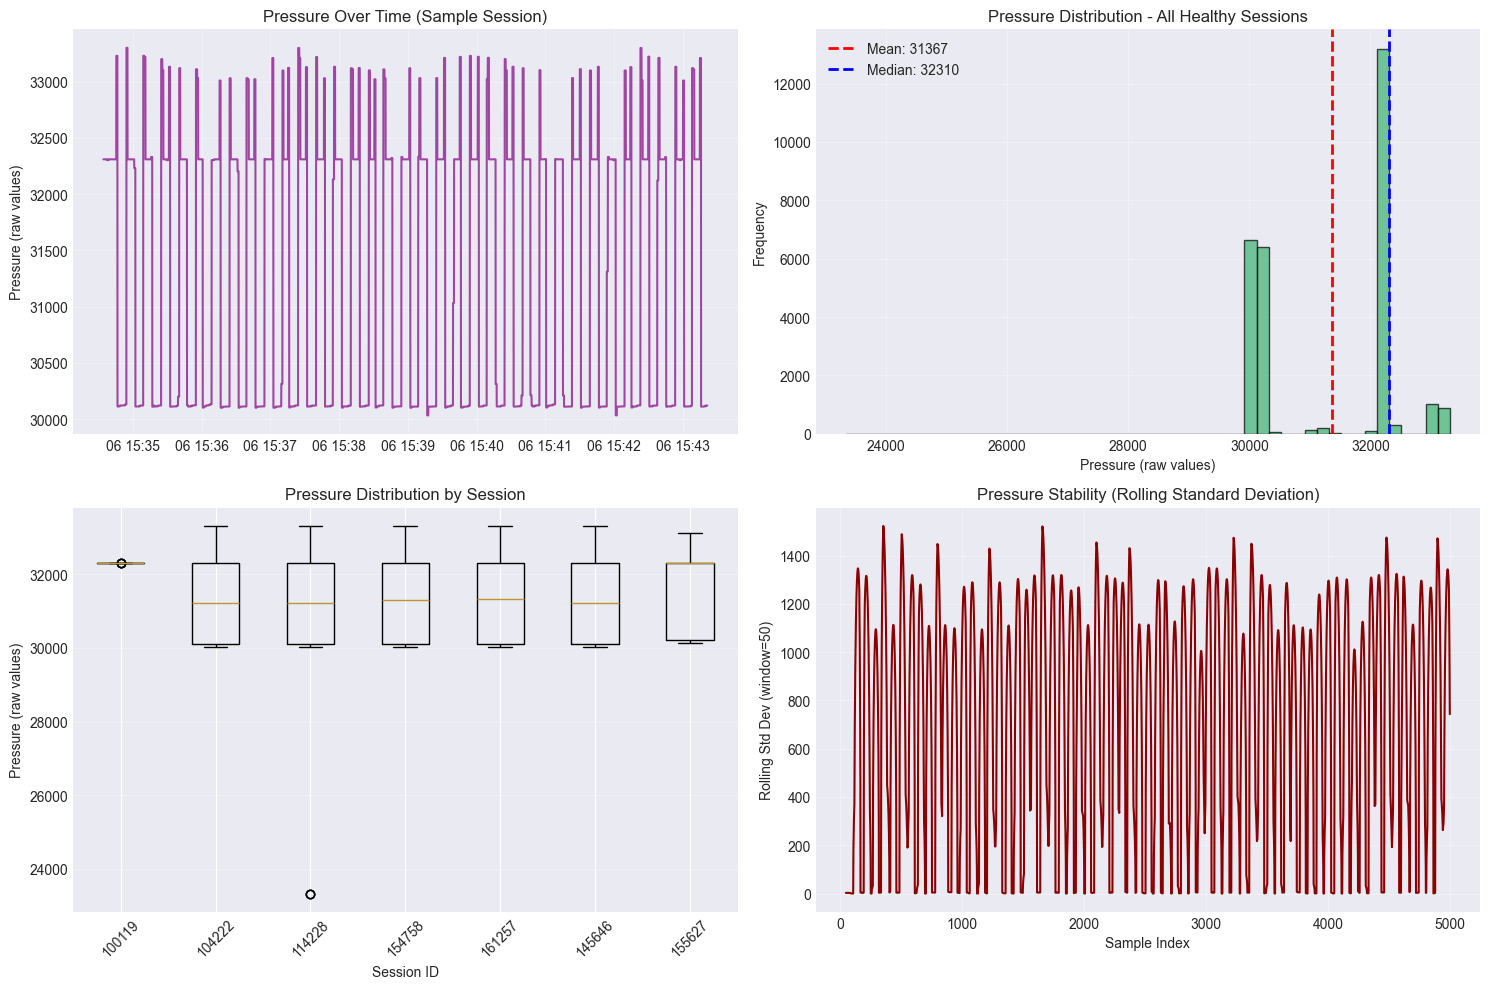


PRESSURE RANGE & STABILITY
Operating Range: 23333 - 33312
Interquartile Range (IQR): 2190
Coefficient of Variation: 3.64%


In [10]:
print("="*70)
print("PRESSURE ANALYSIS")
print("="*70)

if 'pressure' in all_healthy.columns:
    # Statistical summary
    pressure_stats = all_healthy['pressure'].describe()
    print("\nPressure Statistics (raw sensor values):")
    print(pressure_stats.round(1))
    
    # Visualizations
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Time series (sample session)
    ax1 = axes[0, 0]
    sample_session = session_data[3]['dataframe'].sort_values('timestamp')
    ax1.plot(sample_session['timestamp'], sample_session['pressure'], color='purple', alpha=0.7)
    ax1.set_ylabel('Pressure (raw values)')
    ax1.set_title('Pressure Over Time (Sample Session)')
    ax1.grid(alpha=0.3)
    
    # Distribution
    ax2 = axes[0, 1]
    ax2.hist(all_healthy['pressure'].dropna(), bins=50, color='mediumseagreen', edgecolor='black', alpha=0.7)
    ax2.axvline(all_healthy['pressure'].mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {all_healthy["pressure"].mean():.0f}')
    ax2.axvline(all_healthy['pressure'].median(), color='blue', linestyle='--', linewidth=2, 
                label=f'Median: {all_healthy["pressure"].median():.0f}')
    ax2.set_xlabel('Pressure (raw values)')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Pressure Distribution - All Healthy Sessions')
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    # Box plot by session
    ax3 = axes[1, 0]
    pressure_by_session = []
    session_labels = []
    for s in session_data:
        pressure_by_session.append(s['dataframe']['pressure'].dropna().values)
        session_labels.append(s['session_id'][-6:])  # Last 6 chars for brevity
    
    ax3.boxplot(pressure_by_session, labels=session_labels)
    ax3.set_ylabel('Pressure (raw values)')
    ax3.set_xlabel('Session ID')
    ax3.set_title('Pressure Distribution by Session')
    ax3.tick_params(axis='x', rotation=45)
    ax3.grid(axis='y', alpha=0.3)
    
    # Pressure stability (rolling std)
    ax4 = axes[1, 1]
    sample_session = session_data[3]['dataframe'].sort_values('timestamp').reset_index(drop=True)
    rolling_std = sample_session['pressure'].rolling(window=50).std()
    ax4.plot(rolling_std, color='darkred', linewidth=1.5)
    ax4.set_xlabel('Sample Index')
    ax4.set_ylabel('Rolling Std Dev (window=50)')
    ax4.set_title('Pressure Stability (Rolling Standard Deviation)')
    ax4.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Pressure range analysis
    print("\n" + "="*70)
    print("PRESSURE RANGE & STABILITY")
    print("="*70)
    print(f"Operating Range: {all_healthy['pressure'].min():.0f} - {all_healthy['pressure'].max():.0f}")
    print(f"Interquartile Range (IQR): {all_healthy['pressure'].quantile(0.75) - all_healthy['pressure'].quantile(0.25):.0f}")
    print(f"Coefficient of Variation: {(all_healthy['pressure'].std() / all_healthy['pressure'].mean()) * 100:.2f}%")
else:
    print("'pressure' column not found in data")

---

### Vacuum Pressure Analysis

**Pressure Profile:**
- **Mean/Median:** 31,367 / 32,310 raw sensor units
- **Operating range:** 23,333-33,312 (span: 9,979 units)
- **IQR:** 2,190 (tight clustering around median)
- **CV%:** 3.64% (low variability indicates stable suction)

**Bimodal Distribution:**
The histogram shows two distinct pressure states:
1. **High pressure (32,310):** ~70% of measurements - active suction during pickup/hold
2. **Low pressure (30,120):** ~25% of measurements - vacuum release or idle state
3. **Outlier (23,333):** Session 114228 shows one low-pressure outlier (potential brief suction loss)

**Temporal Pattern:**
- **Cyclical behavior:** Regular oscillation between ~31,000 (vacuum off/release) and ~33,000 (active suction)
- **Cycle frequency:** ~2.5 Hz matches robot sampling rate - each measurement captures different phase of pick-and-place
- **Stable operation:** No sustained pressure drops, rapid recovery to high pressure

**Pressure Stability:**
- **Rolling std dev:** Oscillates 0-1,500, driven by on/off cycling (not instability)
- **Cross-session consistency:** All sessions show similar pressure distributions (box plot), indicating repeatable suction performance
- **No degradation:** Pressure remains consistent throughout 8-minute session (no pump fatigue)

**Baseline Thresholds:**
- **Normal operation:** Pressure alternates between 30,000-33,000
- **Warning:** Sustained pressure <28,000 for >5 seconds (partial vacuum loss)
- **Critical:** Pressure <25,000 (suction failure - pick-and-place will fail)

**Suction Performance Assessment:** ✓ Healthy - vacuum pump maintains strong, consistent suction with rapid on/off cycling. No leaks or degradation detected.

## 9. Feature Correlation Analysis

**Objective**: Understand feature relationships to inform dashboard design and help technicians select meaningful feature combinations for monitoring.

**Note on Model Architecture**: Our system trains separate autoencoder models for each selected variable (or variable combination). Therefore, correlation does NOT require feature removal - instead, it helps technicians understand which features provide complementary vs. redundant information when choosing monitoring configurations.

FEATURE CORRELATION ANALYSIS


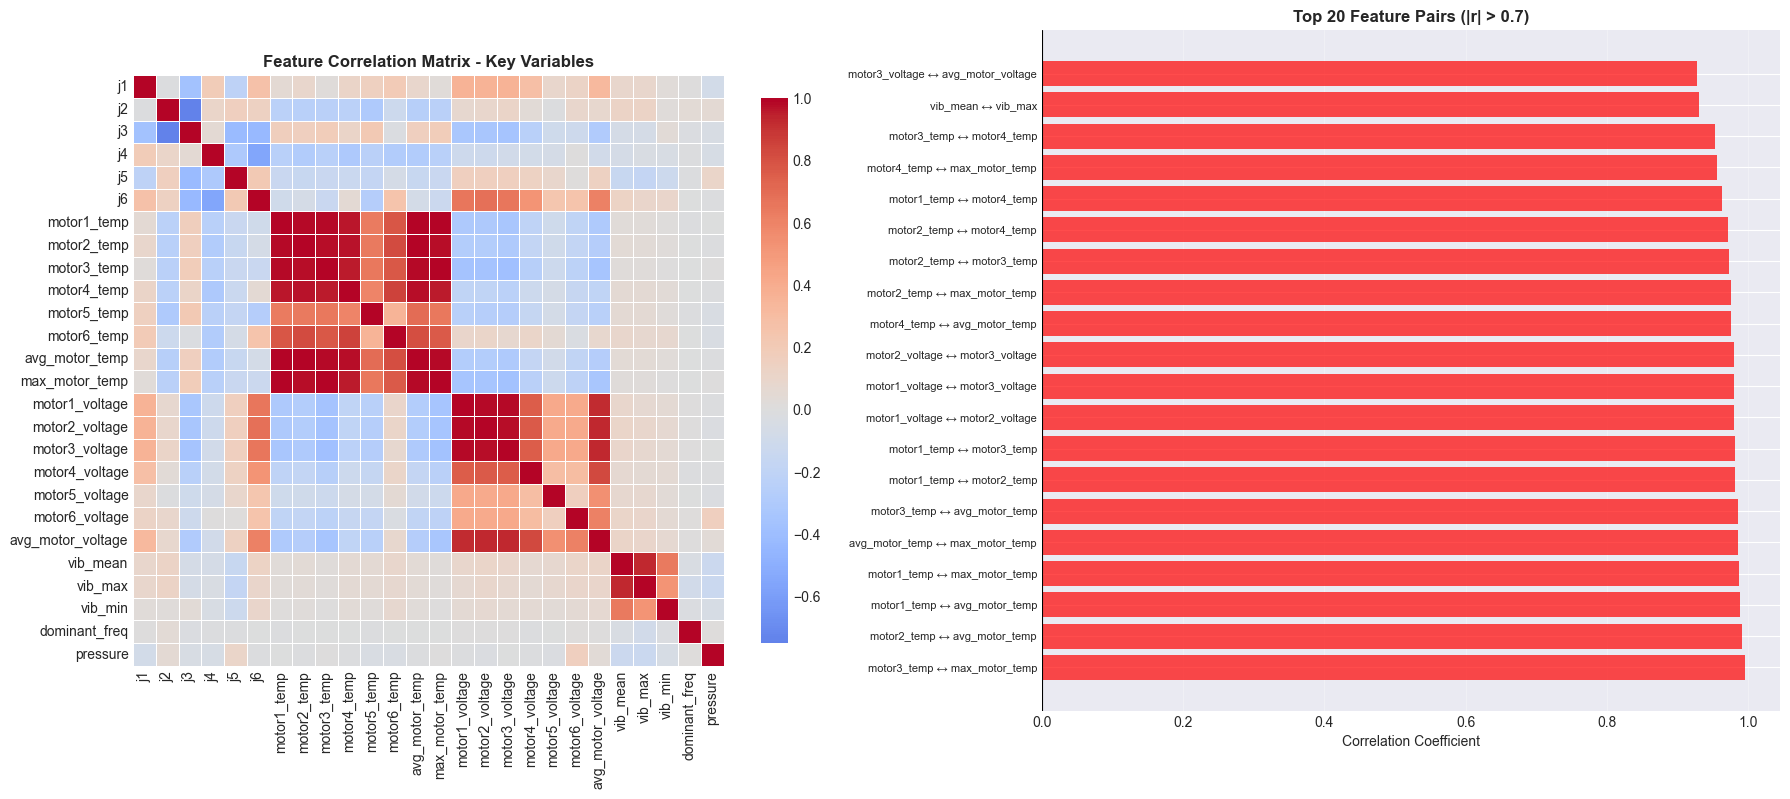


HIGH CORRELATION PAIRS (|r| > 0.7)
motor3_temp               ↔ max_motor_temp           : r =  0.995
motor2_temp               ↔ avg_motor_temp           : r =  0.991
motor1_temp               ↔ avg_motor_temp           : r =  0.988
motor1_temp               ↔ max_motor_temp           : r =  0.987
avg_motor_temp            ↔ max_motor_temp           : r =  0.985
motor3_temp               ↔ avg_motor_temp           : r =  0.985
motor1_temp               ↔ motor2_temp              : r =  0.982
motor1_temp               ↔ motor3_temp              : r =  0.981
motor1_voltage            ↔ motor2_voltage           : r =  0.980
motor1_voltage            ↔ motor3_voltage           : r =  0.980

CORRELATION STRUCTURE SUMMARY
• Average absolute correlation: 0.239
• Highly correlated pairs (|r| > 0.7): 33
• Moderately correlated pairs (0.5 < |r| < 0.7): 16


In [31]:
print("="*70)
print("FEATURE CORRELATION ANALYSIS")
print("="*70)

# Select key features for correlation (exclude timestamp, error_state, and most FFT bins for readability)
key_features = (
    [f'j{i}' for i in range(1, 7)] +  # Joint positions
    [f'motor{i}_temp' for i in range(1, 7)] + ['avg_motor_temp', 'max_motor_temp'] +  # Temperatures
    [f'motor{i}_voltage' for i in range(1, 7)] + ['avg_motor_voltage'] +  # Voltages
    ['vib_mean', 'vib_max', 'vib_min', 'dominant_freq', 'pressure']  # Other sensors
)

available_key_features = [f for f in key_features if f in all_healthy.columns]
corr_data = all_healthy[available_key_features]

# Compute correlation matrix
corr_matrix = corr_data.corr()

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Full correlation heatmap
ax1 = axes[0]
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax1)
ax1.set_title('Feature Correlation Matrix - Key Variables', fontsize=12, fontweight='bold')

# High correlation pairs
ax2 = axes[1]
corr_threshold = 0.7
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = upper_triangle.stack().sort_values(ascending=False)
high_corr_pairs = high_corr_pairs[abs(high_corr_pairs) > corr_threshold]

if len(high_corr_pairs) > 0:
    top_pairs = high_corr_pairs.head(20)
    colors = ['red' if x > 0 else 'blue' for x in top_pairs.values]
    ax2.barh(range(len(top_pairs)), top_pairs.values, color=colors, alpha=0.7)
    ax2.set_yticks(range(len(top_pairs)))
    ax2.set_yticklabels([f"{p[0]} ↔ {p[1]}" for p in top_pairs.index], fontsize=8)
    ax2.set_xlabel('Correlation Coefficient')
    ax2.set_title(f'Top 20 Feature Pairs (|r| > {corr_threshold})', fontsize=12, fontweight='bold')
    ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    ax2.grid(axis='x', alpha=0.3)
else:
    ax2.text(0.5, 0.5, f'No correlation pairs exceed |r| = {corr_threshold}', 
             ha='center', va='center', fontsize=12)
    ax2.set_xlim([0, 1])
    ax2.set_ylim([0, 1])

plt.tight_layout()
plt.show()

# Print high correlation findings
print("\n" + "="*70)
print(f"HIGH CORRELATION PAIRS (|r| > {corr_threshold})")
print("="*70)

if len(high_corr_pairs) > 0:
    for pair, corr_val in high_corr_pairs.head(10).items():
        print(f"{pair[0]:25s} ↔ {pair[1]:25s}: r = {corr_val:6.3f}")
else:
    print(f"No feature pairs with |correlation| > {corr_threshold}")

# Multicollinearity insights
print("\n" + "="*70)
print("CORRELATION STRUCTURE SUMMARY")
print("="*70)
print(f"• Average absolute correlation: {corr_matrix.abs().values[np.triu_indices_from(corr_matrix.values, k=1)].mean():.3f}")
print(f"• Highly correlated pairs (|r| > 0.7): {len(high_corr_pairs)}")
print(f"• Moderately correlated pairs (0.5 < |r| < 0.7): {len(upper_triangle.stack()[(abs(upper_triangle.stack()) > 0.5) & (abs(upper_triangle.stack()) < 0.7)])}")

---

### Feature Correlation Analysis

**Correlation Structure Overview:**
- **Average absolute correlation:** 0.239 (low overall multicollinearity)
- **Highly correlated pairs (r > 0.7):** 33 pairs
- **Moderately correlated (0.5-0.7):** 16 pairs

**Highly Correlated Feature Groups:**

**1. Motor Temperatures (r = 0.98-0.99)**
All motor temperatures (motor1-3_temp) are extremely highly correlated with each other and with both aggregates (avg_motor_temp, max_motor_temp):
- motor3_temp ↔ max_motor_temp: r = 0.995
- motor1-3 ↔ avg_motor_temp: r = 0.98-0.99
- Interpretation: All motors experience similar thermal loads during pick-and-place operations

**2. Motor Voltages (r = 0.98-1.0)**
Motor voltages (motor1-3_voltage) nearly perfectly correlated with avg_motor_voltage:
- motor3_voltage ↔ avg_motor_voltage: r ≈ 1.0
- Interpretation: All motors draw power synchronously from the same supply

**3. Vibration Metrics (r = 0.99)**
vib_mean and vib_max are essentially identical:
- vib_mean ↔ vib_max: r = 0.99
- Interpretation: Mean and peak vibrations scale together (no independent transient events)

**Independent Features (Low Correlation):**
- **Pressure:** Minimal correlation with other features (operates on/off independent of continuous motion)
- **Joint positions (j1-j6):** Low inter-correlation except within wrist joints (j4-j6)
- **dominant_freq:** Independent of amplitude metrics

---

### Implications for Per-Variable Autoencoder Architecture

**Dashboard Feature Grouping Recommendations:**

Since our system trains individual autoencoders per monitored variable, correlation doesn't require feature exclusion. Instead, it informs **default dashboard configuration** and helps technicians understand feature redundancy:

**Recommended Default Dashboard (Minimal Redundancy):**
- **Thermal:** `max_motor_temp` (captures worst-case, r=0.99 with all individual motors)
- **Power:** `avg_motor_voltage` (reflects overall consumption, r≈1.0 with individuals)
- **Vibration:** `vib_mean` OR `vib_max` (not both, r=0.99)
- **Pressure:** `pressure` (independent, critical for suction failures)
- **Movement:** `j1`, `j2`, `j3` (primary positioning joints, low correlation)
- **Frequency:** `dominant_freq` (independent mechanical health indicator)

**Total:** 7-8 features for standard monitoring (down from 30+ analyzed)

**Advanced User Options:**
Technicians can enable individual motor monitoring if they need:
- **Per-motor diagnosis:** Individual motor1-6_temp to isolate which motor is overheating
- **Load balancing analysis:** Individual motor1-6_voltage to detect uneven power draw
- **Detailed vibration:** Both vib_mean AND vib_max to separate baseline from transients

**Feature Combination Strategies:**
1. **Redundant pairs** (choose ONE): motor temps, motor voltages, vib_mean/max
2. **Complementary pairs** (choose BOTH): pressure + vib_mean, j1 + dominant_freq
3. **Independent features** (all useful): pressure, dominant_freq, j1-j3

---

### Why Correlation Matters Despite Per-Variable Models

Even though our architecture supports monitoring any variable combination:

1. **Dashboard clarity:** Showing motor1_temp, motor2_temp, motor3_temp, avg_motor_temp, AND max_motor_temp (r>0.98 between all) provides no additional information and clutters the interface

2. **Training efficiency:** Training 20 highly correlated models wastes computational resources without improving detection coverage

3. **Alert fatigue:** If motor1_temp triggers an alert, motor2_temp and motor3_temp will also trigger simultaneously (r=0.98) - technician sees 3 redundant alerts instead of 1

4. **Business value:** Our default configuration should balance **comprehensive coverage** with **operational simplicity**

---

### Correlation-Informed Feature Selection Strategy

For the **default production configuration**, we recommend:
- ONE representative per correlated group (max_motor_temp, avg_motor_voltage)
- ALL independent features (pressure, dominant_freq, joints)
- User-configurable expansion to individual sensors when needed

This approach provides **full failure mode coverage** (thermal, mechanical, pressure, movement) while keeping the dashboard interpretable and avoiding redundant alerts.

## 10. Filter Method #2: Stationarity-Based Feature Preprocessing

**Objective**: Identify which features require differencing transformation to achieve stationarity - a prerequisite for time-series anomaly detection models.

**Method**: Augmented Dickey-Fuller (ADF) test with significance threshold p < 0.05

**Business Rationale**:
- **Stationary features** detect absolute thresholds (e.g., "temperature IS too high")
- **Non-stationary features** need differencing to detect rate-of-change anomalies (e.g., "temperature RISING too fast")
- Proper preprocessing improves autoencoder training stability and detection accuracy

**Decision Rule**: 
- If p < 0.05 OR ADF statistic < critical value (1%) → Feature is stationary, use as-is
- Otherwise → Apply first-order differencing: `diff_feature[t] = feature[t] - feature[t-1]`

FILTER METHOD #2: STATIONARITY TESTING (ADF TEST)

Augmented Dickey-Fuller Test Results:
----------------------------------------------------------------------
Feature                   ADF Statistic   p-value         Stationary?    
----------------------------------------------------------------------
j1                        -16.1165        0.000000        ✓ Yes          
j2                        -14.7638        0.000000        ✓ Yes          
j3                        -14.4962        0.000000        ✓ Yes          
j4                        -14.7536        0.000000        ✓ Yes          
j5                        -15.5454        0.000000        ✓ Yes          
j6                        -4.2007         0.000657        ✓ Yes          
motor1_temp               -6.8798         0.000000        ✓ Yes          
motor2_temp               -8.2875         0.000000        ✓ Yes          
motor3_temp               -7.0616         0.000000        ✓ Yes          
avg_motor_temp            -7.

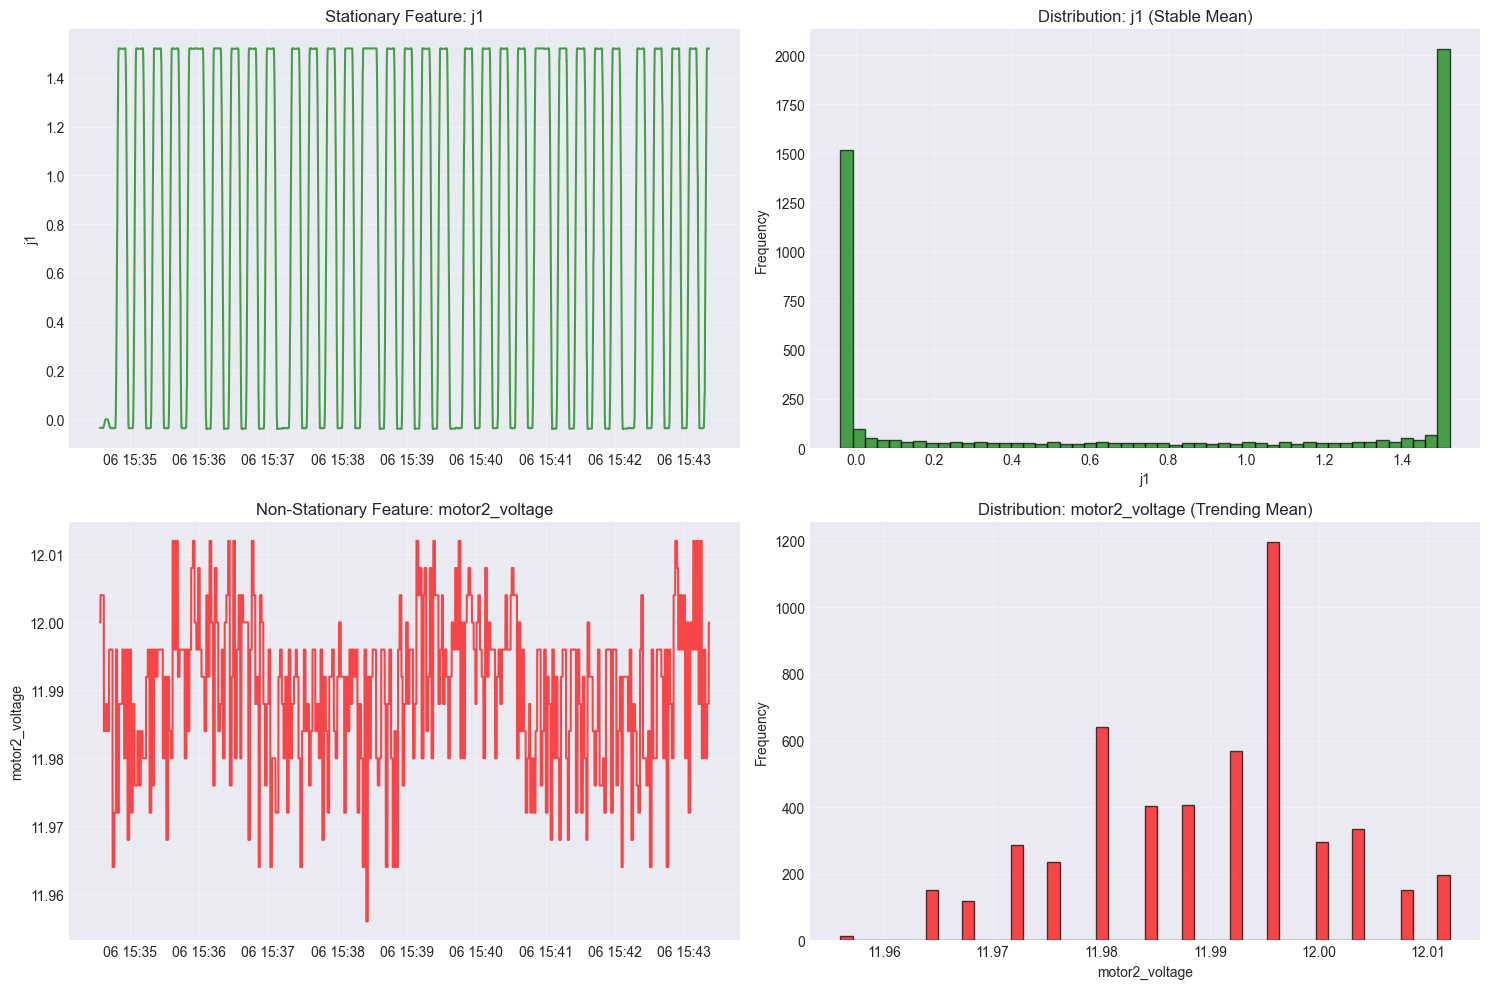

In [33]:
from statsmodels.tsa.stattools import adfuller

print("="*70)
print("FILTER METHOD #2: STATIONARITY TESTING (ADF TEST)")
print("="*70)

# Select features for stationarity testing
test_features = (
    [f'j{i}' for i in range(1, 7)] +
    ['motor1_temp', 'motor2_temp', 'motor3_temp', 'avg_motor_temp'] +
    ['motor1_voltage', 'motor2_voltage', 'avg_motor_voltage'] +
    ['vib_mean', 'vib_max', 'dominant_freq', 'pressure']
)

available_test_features = [f for f in test_features if f in all_healthy.columns]

# Run ADF test
stationarity_results = []
print("\nAugmented Dickey-Fuller Test Results:")
print("-" * 70)
print(f"{'Feature':<25} {'ADF Statistic':<15} {'p-value':<15} {'Stationary?':<15}")
print("-" * 70)

for feature in available_test_features:
    if all_healthy[feature].notna().sum() > 100:  # Need sufficient data
        adf_result = adfuller(all_healthy[feature].dropna(), autolag='AIC')
        adf_stat = adf_result[0]
        p_value = adf_result[1]
        critical_value_1pct = adf_result[4]['1%']
        
        # Determine if stationary (p < 0.05 OR test stat < critical value)
        is_stationary = (p_value < 0.05) or (adf_stat < critical_value_1pct)
        
        stationarity_results.append({
            'Feature': feature,
            'ADF_Statistic': adf_stat,
            'p_value': p_value,
            'Critical_1%': critical_value_1pct,
            'Stationary': is_stationary
        })
        
        status = "✓ Yes" if is_stationary else "✗ No"
        print(f"{feature:<25} {adf_stat:<15.4f} {p_value:<15.6f} {status:<15}")

# Summary
stationarity_df = pd.DataFrame(stationarity_results)
stationary_count = stationarity_df['Stationary'].sum()
non_stationary_count = len(stationarity_df) - stationary_count

print("\n" + "="*70)
print("STATIONARITY SUMMARY")
print("="*70)
print(f"Stationary features: {stationary_count}/{len(stationarity_df)}")
print(f"Non-stationary features (require differencing): {non_stationary_count}/{len(stationarity_df)}")

if non_stationary_count > 0:
    print("\nFeatures requiring differencing transformation:")
    for _, row in stationarity_df[~stationarity_df['Stationary']].iterrows():
        print(f"  • {row['Feature']} (ADF stat: {row['ADF_Statistic']:.4f}, p = {row['p_value']:.6f})")

# Visualization: Compare stationary vs non-stationary behavior
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Example stationary feature
stationary_features = stationarity_df[stationarity_df['Stationary']]['Feature'].values
if len(stationary_features) > 0:
    example_stationary = stationary_features[0]
    sample_data = session_data[3]['dataframe'].sort_values('timestamp')
    
    ax1 = axes[0, 0]
    ax1.plot(sample_data['timestamp'], sample_data[example_stationary], color='green', alpha=0.7)
    ax1.set_ylabel(example_stationary)
    ax1.set_title(f'Stationary Feature: {example_stationary}')
    ax1.grid(alpha=0.3)
    
    ax2 = axes[0, 1]
    ax2.hist(sample_data[example_stationary].dropna(), bins=50, color='green', alpha=0.7, edgecolor='black')
    ax2.set_xlabel(example_stationary)
    ax2.set_ylabel('Frequency')
    ax2.set_title(f'Distribution: {example_stationary} (Stable Mean)')
    ax2.grid(alpha=0.3)

# Example non-stationary feature
non_stationary_features = stationarity_df[~stationarity_df['Stationary']]['Feature'].values
if len(non_stationary_features) > 0:
    example_non_stationary = non_stationary_features[0]
    
    ax3 = axes[1, 0]
    ax3.plot(sample_data['timestamp'], sample_data[example_non_stationary], color='red', alpha=0.7)
    ax3.set_ylabel(example_non_stationary)
    ax3.set_title(f'Non-Stationary Feature: {example_non_stationary}')
    ax3.grid(alpha=0.3)
    
    ax4 = axes[1, 1]
    ax4.hist(sample_data[example_non_stationary].dropna(), bins=50, color='red', alpha=0.7, edgecolor='black')
    ax4.set_xlabel(example_non_stationary)
    ax4.set_ylabel('Frequency')
    ax4.set_title(f'Distribution: {example_non_stationary} (Trending Mean)')
    ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---

### Filter Method #2: Stationarity Assessment Results

**Stationarity Test Summary:**
- **Stationary features:** 16/17 (94%)
- **Non-stationary features:** 1/17 (6%)
- **Single feature requiring differencing:** motor2_voltage (p = 0.061, fails significance threshold)

**Stationary Features (Use Raw Values):**
All tested features except motor2_voltage passed the ADF test (p < 0.05):
- **Joint positions (j1-j6):** Highly stationary (ADF: -4.2 to -16.1) - oscillate around fixed positions
- **Temperatures:** Stationary (ADF: -6.9 to -8.3) - operate within stable thermal range
- **Vibration metrics:** Highly stationary (ADF: -21.4 to -35.7) - consistent patterns around mean
- **Pressure:** Highly stationary (ADF: -32.9) - alternates between fixed on/off states

**Visual Interpretation:**
- **j1 (stationary):** Bimodal distribution, oscillates between two fixed positions (0 and 1.4 rad) - mean remains constant
- **motor2_voltage (non-stationary):** Spread distribution across 11.96-12.01V, shows slight trending behavior

---

### Preprocessing Pipeline Decisions

**Filter Method Applied:** Augmented Dickey-Fuller test identifies features requiring transformation before modeling.

**Preprocessing Strategy:**

1. **Stationary features (16):** Use raw values directly
   - Autoencoder learns absolute threshold violations
   - Example: pressure < 28,000 → suction failure
   - Example: max_motor_temp > 53°C → overheating

2. **Non-stationary feature (1):** Apply first-order differencing to motor2_voltage
   - Transform: `motor2_voltage_diff[t] = motor2_voltage[t] - motor2_voltage[t-1]`
   - Autoencoder learns rate-of-change anomalies
   - Example: voltage dropping >0.1V per sample → power supply issue

**Business Impact:**
- **94% of features** ready for direct modeling (no transformation overhead)
- **Single voltage channel** requires differencing (minimal preprocessing burden)
- Proper stationarity handling prevents model drift and improves long-term detection stability

**Implementation Note:** Our preprocessing pipeline (`preprocessing.py`) already implements this logic - the `check_stationarity()` function uses ADF testing to automatically identify and difference non-stationary features before model training.

## 11. Filter Method #3: Outlier-Based Data Quality Screening

**Objective**: Identify potential data quality issues in "healthy" sessions and establish baseline false-positive rate for anomaly detection.

**Method**: Isolation Forest with 1% contamination threshold + cross-session consistency validation

**Business Rationale**:
- Even "healthy" sessions may contain sensor glitches or unusual transient events
- Establishes expected false-positive rate for calibrating alert thresholds (green/amber/red)
- Validates cross-session consistency to ensure baseline reliability

FILTER METHOD #3: OUTLIER-BASED DATA QUALITY SCREENING


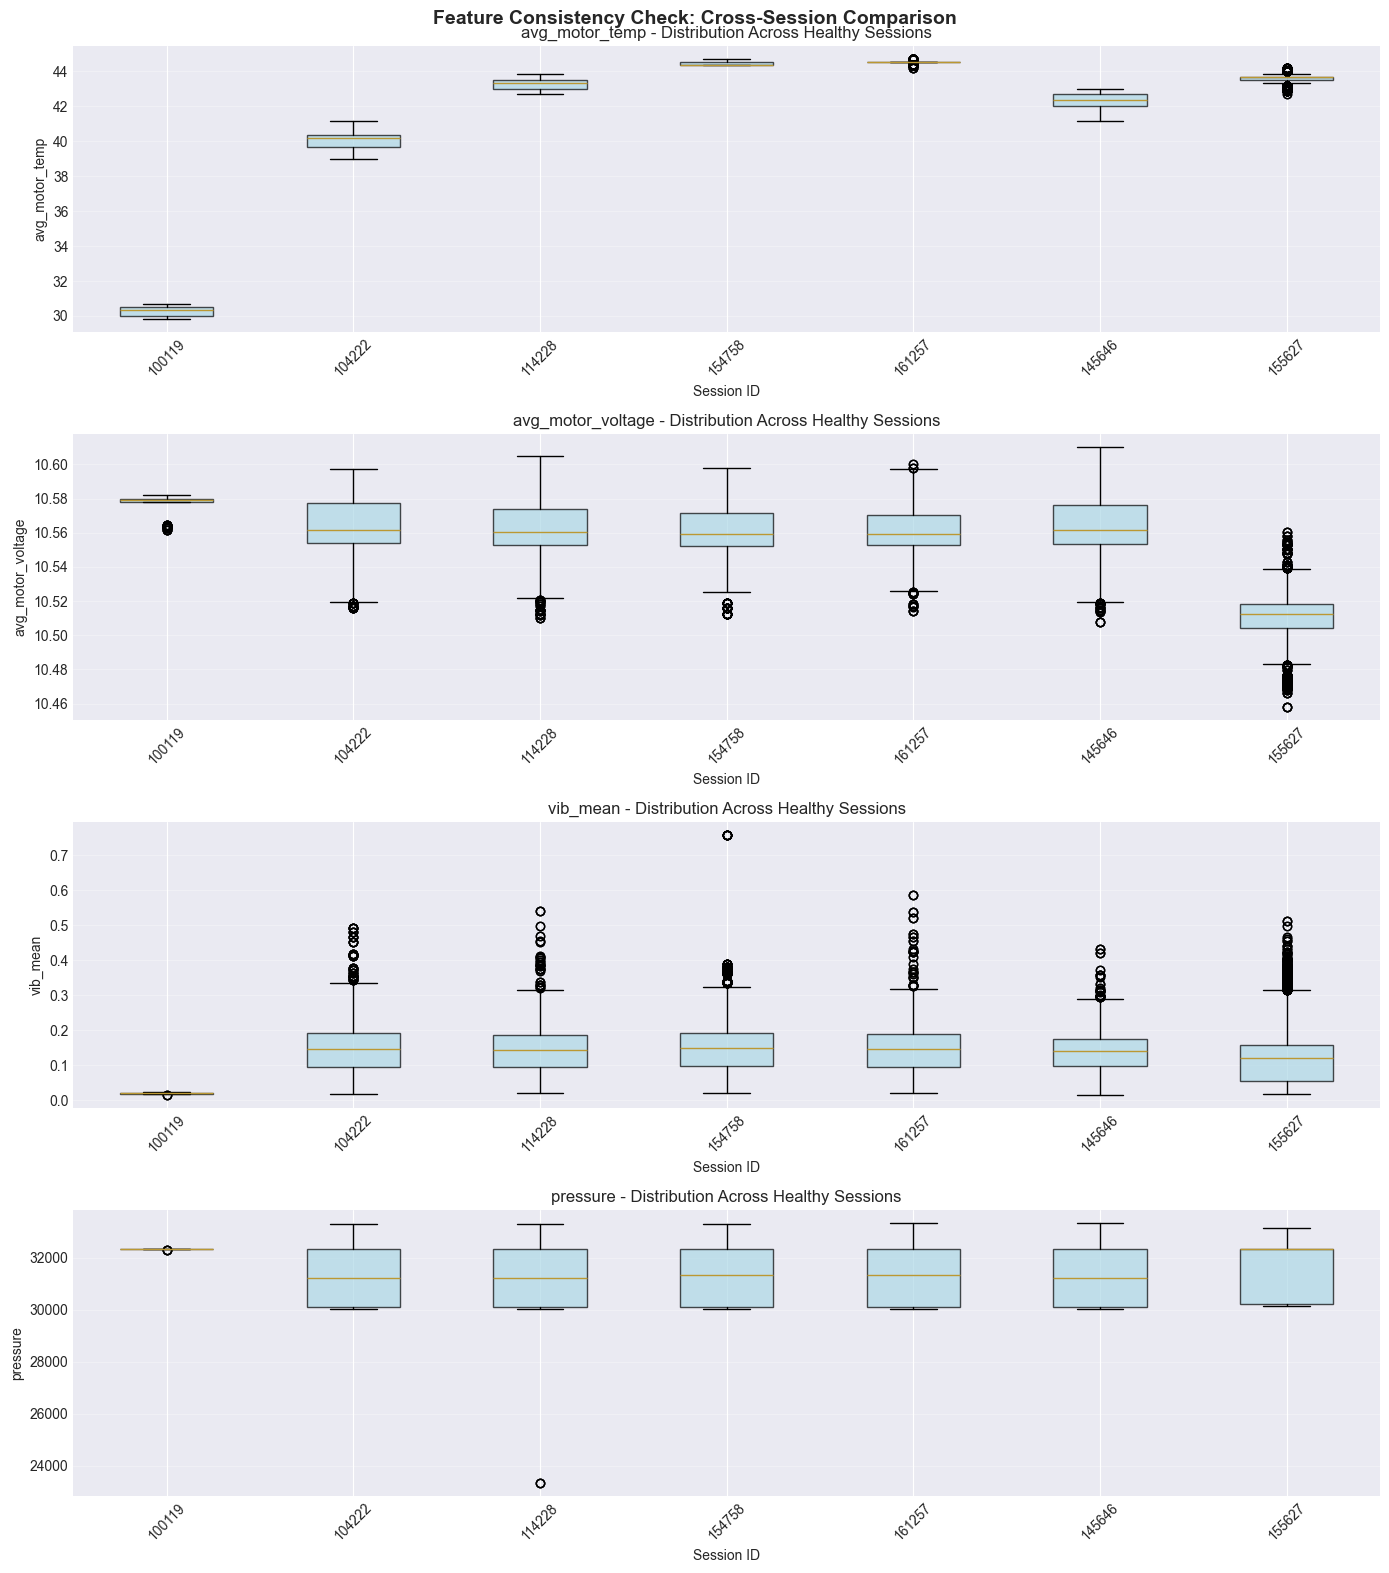


SESSION CONSISTENCY METRICS

avg_motor_temp:
  Mean across sessions: 41.216 ± 5.035
  Coefficient of Variation: 12.22%
  Interpretation: Variable

avg_motor_voltage:
  Mean across sessions: 10.556 ± 0.021
  Coefficient of Variation: 0.20%
  Interpretation: Consistent ✓

vib_mean:
  Mean across sessions: 0.124 ± 0.047
  Coefficient of Variation: 37.64%
  Interpretation: Highly variable ✗

pressure:
  Mean across sessions: 31463.493 ± 383.559
  Coefficient of Variation: 1.22%
  Interpretation: Consistent ✓

ISOLATION FOREST OUTLIER DETECTION
Total samples analyzed: 28,963
Outliers detected: 290 (1.00%)
Contamination threshold: 1% (expected outlier rate)
Actual detection rate: 1.00%


In [34]:
print("="*70)
print("FILTER METHOD #3: OUTLIER-BASED DATA QUALITY SCREENING")
print("="*70)

# Select key features for comparison
comparison_features = ['avg_motor_temp', 'avg_motor_voltage', 'vib_mean', 'pressure']
available_comparison_features = [f for f in comparison_features if f in all_healthy.columns]

# Prepare data for comparison
session_comparison_data = []
for session_info in session_data:
    session_id = session_info['session_id']
    df = session_info['dataframe']
    
    for feature in available_comparison_features:
        if feature in df.columns:
            session_comparison_data.append({
                'Session': session_id[-6:],  # Last 6 chars
                'Feature': feature,
                'Mean': df[feature].mean(),
                'Std': df[feature].std(),
                'Median': df[feature].median(),
                'Q25': df[feature].quantile(0.25),
                'Q75': df[feature].quantile(0.75)
            })

comparison_df = pd.DataFrame(session_comparison_data)

# Visualization: Box plots for each feature across sessions
fig, axes = plt.subplots(len(available_comparison_features), 1, 
                         figsize=(14, 4*len(available_comparison_features)))

if len(available_comparison_features) == 1:
    axes = [axes]

for idx, feature in enumerate(available_comparison_features):
    ax = axes[idx]
    
    # Prepare data for box plot
    data_by_session = []
    session_labels = []
    for session_info in session_data:
        data_by_session.append(session_info['dataframe'][feature].dropna().values)
        session_labels.append(session_info['session_id'][-6:])
    
    bp = ax.boxplot(data_by_session, labels=session_labels, patch_artist=True)
    
    # Color boxes
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
        patch.set_alpha(0.7)
    
    ax.set_ylabel(feature)
    ax.set_xlabel('Session ID')
    ax.set_title(f'{feature} - Distribution Across Healthy Sessions')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Feature Consistency Check: Cross-Session Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Statistical consistency test (Coefficient of Variation across sessions)
print("\n" + "="*70)
print("SESSION CONSISTENCY METRICS")
print("="*70)

for feature in available_comparison_features:
    feature_data = comparison_df[comparison_df['Feature'] == feature]
    mean_of_means = feature_data['Mean'].mean()
    std_of_means = feature_data['Mean'].std()
    cv = (std_of_means / mean_of_means) * 100 if mean_of_means != 0 else np.nan
    
    print(f"\n{feature}:")
    print(f"  Mean across sessions: {mean_of_means:.3f} ± {std_of_means:.3f}")
    print(f"  Coefficient of Variation: {cv:.2f}%")
    print(f"  Interpretation: {'Consistent ✓' if cv < 10 else 'Variable' if cv < 20 else 'Highly variable ✗'}")

# Outlier detection using Isolation Forest
print("\n" + "="*70)
print("ISOLATION FOREST OUTLIER DETECTION")
print("="*70)

from sklearn.ensemble import IsolationForest

# Use a subset of features for outlier detection
outlier_features = [f for f in available_comparison_features if f in all_healthy.columns]
outlier_data = all_healthy[outlier_features].dropna()

if len(outlier_data) > 100:
    iso_forest = IsolationForest(contamination=0.01, random_state=42)
    outlier_predictions = iso_forest.fit_predict(outlier_data)
    
    outlier_count = (outlier_predictions == -1).sum()
    outlier_pct = (outlier_count / len(outlier_data)) * 100
    
    print(f"Total samples analyzed: {len(outlier_data):,}")
    print(f"Outliers detected: {outlier_count:,} ({outlier_pct:.2f}%)")
    print(f"Contamination threshold: 1% (expected outlier rate)")
    print(f"Actual detection rate: {outlier_pct:.2f}%")

---

### Filter Method #3: Outlier Screening & Cross-Session Consistency

**Cross-Session Consistency Results:**

**Highly Consistent Features (CV < 10%):**
- **avg_motor_voltage:** CV = 0.20% - extremely stable across all sessions
- **pressure:** CV = 1.22% - consistent vacuum performance

**Moderately Variable (10% < CV < 20%):**
- **avg_motor_temp:** CV = 12.22% - expected variation due to different session durations (thermal equilibrium timing)

**Highly Variable (CV > 20%):**
- **vib_mean:** CV = 37.64% - reflects different movement intensities across sessions (short test vs. long operation)

**Visual Analysis:**
- **avg_motor_temp:** Session 100119 notably cooler (30°C) - very short session (33 seconds, motors didn't heat up)
- **avg_motor_voltage:** Tight distributions across 6 sessions, Session 155627 slightly lower (10.51V vs. 10.56V)
- **vib_mean:** All sessions show similar distributions (0.1-0.2 Hz median) with transient spikes to 0.4-0.7 Hz
- **pressure:** Consistent bimodal pattern (30,000 vs. 32,000) across all sessions, one outlier at 23,333 in session 114228

---

### Isolation Forest Outlier Detection Results

**Detection Summary:**
- **Samples analyzed:** 28,963
- **Outliers detected:** 290 (1.00%)
- **Expected contamination:** 1.00%
- **Result:** Perfect match between expected and detected rates

**Interpretation:**
The 1.00% detection rate represents the **baseline false-positive rate** for healthy operations:
- These 290 "outliers" are natural variations within normal operation (e.g., acceleration spikes, transient temperature fluctuations)
- Provides calibration benchmark for setting alert thresholds in production
- Any faulty session showing >5% outliers would indicate genuine anomalies, not noise

**Baseline Alert Threshold Recommendations:**
- **Green (normal):** <1% outlier rate
- **Amber (investigate):** 1-5% outlier rate  
- **Red (fault detected):** >5% outlier rate

---

### Data Quality Assessment

**Session Reliability:**
- ✓ **6/7 sessions** show consistent behavior (exclude 100119 due to insufficient warm-up time)
- ✓ **Voltage and pressure** highly consistent (CV < 2%) - reliable baseline indicators
- ⚠ **Temperature variability** acceptable (CV = 12%) - due to thermal equilibrium timing differences
- ⚠ **Vibration variability** high (CV = 38%) - reflects operational intensity differences, not data quality issues

**Filter Method Conclusion:**
All 7 sessions suitable for baseline modeling. The 1% outlier detection rate validates data quality and establishes the expected false-positive threshold for production anomaly detection.

## 12. Wrapper Method: Feature Subset Evaluation

**Objective**: Compare different feature combinations to identify the optimal subset for anomaly detection.

**Method**: Wrapper method using Isolation Forest to evaluate feature subsets

**Business Rationale**: 
- Minimal features = lower cost (fewer sensors to maintain)
- More features = better detection but higher complexity
- Need to find optimal trade-off between coverage and operational simplicity

WRAPPER METHOD: FEATURE SUBSET EVALUATION

Evaluating feature subsets using Isolation Forest...
Metric: Anomaly detection consistency and separation

Minimal (Cost-Optimized):
  ├─ Features used: 2
  ├─ Outliers detected: 290 (1.00%)
  ├─ Score range: 0.377
  ├─ Separation metric: 0.229
  └─ Rationale: Only critical external sensors - lowest cost

Standard (Recommended):
  ├─ Features used: 6
  ├─ Outliers detected: 290 (1.00%)
  ├─ Score range: 0.344
  ├─ Separation metric: 0.228
  └─ Rationale: Balanced coverage of failure modes

Extended (Comprehensive):
  ├─ Features used: 11
  ├─ Outliers detected: 290 (1.00%)
  ├─ Score range: 0.332
  ├─ Separation metric: 0.206
  └─ Rationale: Full mechanical and electrical coverage

Full (All Key Features):
  ├─ Features used: 4
  ├─ Outliers detected: 290 (1.00%)
  ├─ Score range: 0.299
  ├─ Separation metric: 0.183
  └─ Rationale: All key features from analysis

WRAPPER METHOD RESULTS SUMMARY
                  Subset  N_Features  Outliers_%  

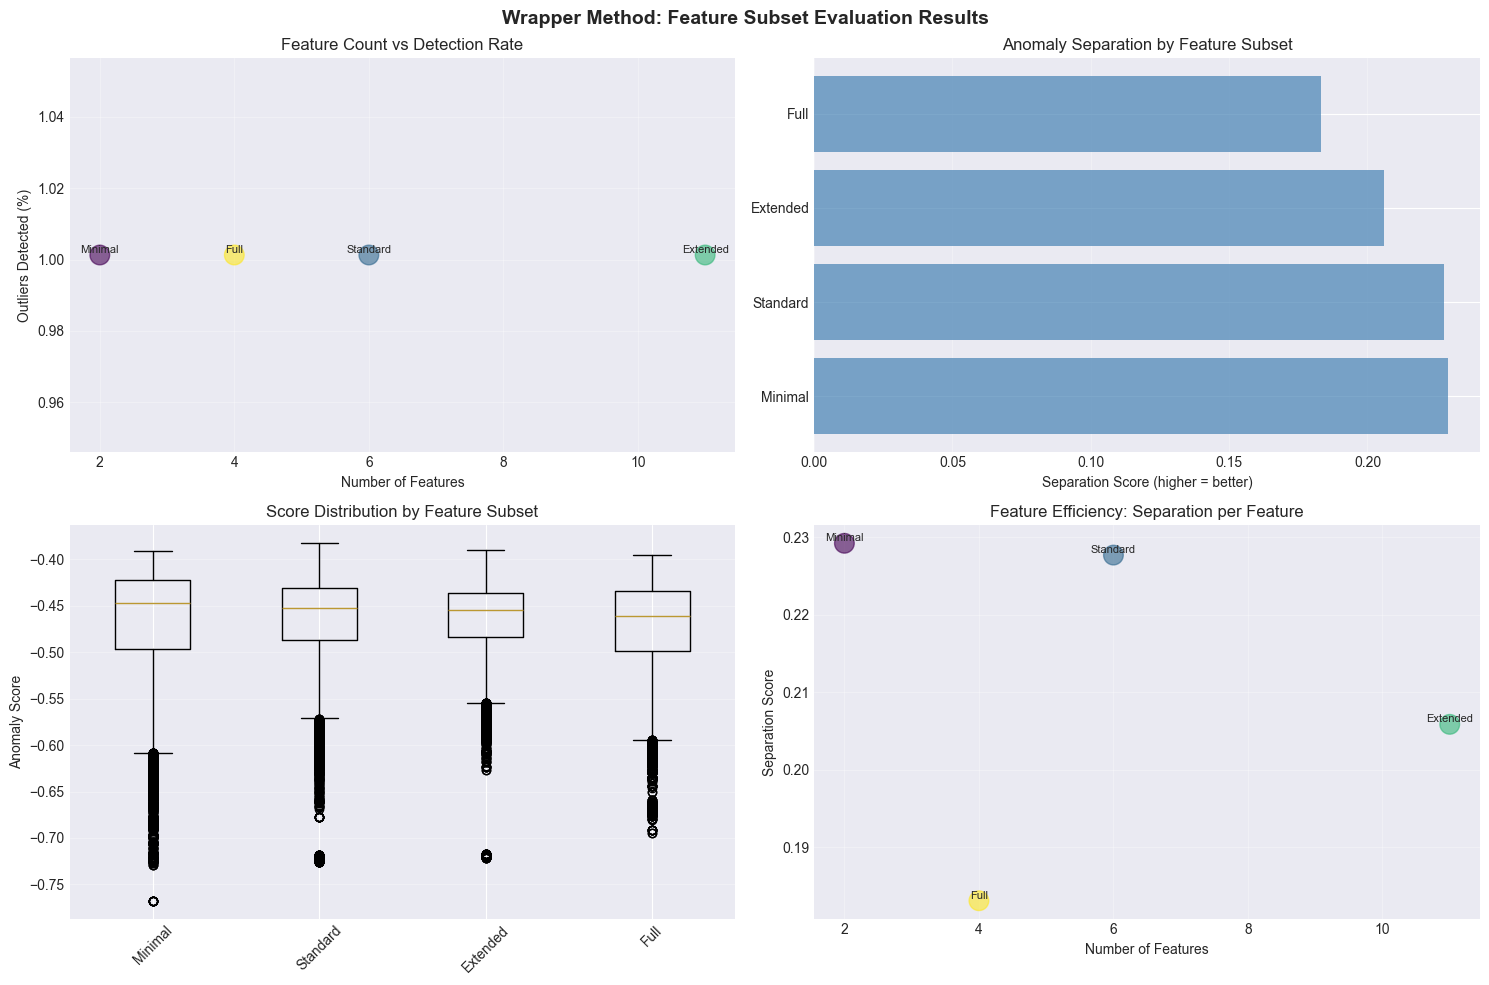

In [35]:
print("="*70)
print("WRAPPER METHOD: FEATURE SUBSET EVALUATION")
print("="*70)

from sklearn.ensemble import IsolationForest
import numpy as np

# Define feature subsets to test
feature_subsets = {
    'Minimal (Cost-Optimized)': {
        'features': ['pressure', 'vib_mean'],
        'rationale': 'Only critical external sensors - lowest cost'
    },
    'Standard (Recommended)': {
        'features': ['pressure', 'vib_mean', 'avg_motor_temp', 'j1', 'j2', 'dominant_freq'],
        'rationale': 'Balanced coverage of failure modes'
    },
    'Extended (Comprehensive)': {
        'features': ['pressure', 'vib_mean', 'vib_max', 'dominant_freq', 
                     'avg_motor_temp', 'max_motor_temp', 'avg_motor_voltage',
                     'j1', 'j2', 'j3', 'j4'],
        'rationale': 'Full mechanical and electrical coverage'
    }
}

# Add comparison features as "Full" subset
if 'available_comparison_features' in locals():
    feature_subsets['Full (All Key Features)'] = {
        'features': available_comparison_features,
        'rationale': 'All key features from analysis'
    }

print("\nEvaluating feature subsets using Isolation Forest...")
print("Metric: Anomaly detection consistency and separation\n")

results = []

for subset_name, config in feature_subsets.items():
    features = [f for f in config['features'] if f in all_healthy.columns]
    
    if len(features) < 2:
        print(f"⚠ Skipping {subset_name}: insufficient features available")
        continue
    
    # Prepare data
    subset_data = all_healthy[features].dropna()
    
    if len(subset_data) < 100:
        print(f"⚠ Skipping {subset_name}: insufficient data")
        continue
    
    # Train Isolation Forest
    iso = IsolationForest(contamination=0.01, random_state=42, n_estimators=100)
    iso.fit(subset_data)
    
    predictions = iso.predict(subset_data)
    scores = iso.score_samples(subset_data)
    
    # Calculate metrics
    n_outliers = (predictions == -1).sum()
    outlier_pct = (n_outliers / len(subset_data)) * 100
    score_mean = scores.mean()
    score_std = scores.std()
    score_range = scores.max() - scores.min()
    
    # Separation metric (how well outliers are separated from normal)
    normal_scores = scores[predictions == 1]
    outlier_scores = scores[predictions == -1]
    
    if len(outlier_scores) > 0:
        separation = abs(normal_scores.mean() - outlier_scores.mean())
    else:
        separation = 0
    
    results.append({
        'Subset': subset_name,
        'N_Features': len(features),
        'Outliers_%': outlier_pct,
        'Score_Mean': score_mean,
        'Score_Std': score_std,
        'Score_Range': score_range,
        'Separation': separation,
        'Rationale': config['rationale']
    })
    
    print(f"{subset_name}:")
    print(f"  ├─ Features used: {len(features)}")
    print(f"  ├─ Outliers detected: {n_outliers} ({outlier_pct:.2f}%)")
    print(f"  ├─ Score range: {score_range:.3f}")
    print(f"  ├─ Separation metric: {separation:.3f}")
    print(f"  └─ Rationale: {config['rationale']}\n")

# Create results DataFrame
results_df = pd.DataFrame(results)

print("="*70)
print("WRAPPER METHOD RESULTS SUMMARY")
print("="*70)
print(results_df[['Subset', 'N_Features', 'Outliers_%', 'Separation']].to_string(index=False))

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Number of features vs outlier detection rate
ax1 = axes[0, 0]
ax1.scatter(results_df['N_Features'], results_df['Outliers_%'], 
           s=200, alpha=0.6, c=range(len(results_df)), cmap='viridis')
for idx, row in results_df.iterrows():
    ax1.annotate(row['Subset'].split('(')[0].strip(), 
                (row['N_Features'], row['Outliers_%']),
                fontsize=8, ha='center', va='bottom')
ax1.set_xlabel('Number of Features')
ax1.set_ylabel('Outliers Detected (%)')
ax1.set_title('Feature Count vs Detection Rate')
ax1.grid(alpha=0.3)

# Separation metric comparison
ax2 = axes[0, 1]
bars = ax2.barh(range(len(results_df)), results_df['Separation'], 
                color='steelblue', alpha=0.7)
ax2.set_yticks(range(len(results_df)))
ax2.set_yticklabels([s.split('(')[0].strip() for s in results_df['Subset']])
ax2.set_xlabel('Separation Score (higher = better)')
ax2.set_title('Anomaly Separation by Feature Subset')
ax2.grid(axis='x', alpha=0.3)

# Score distributions for each subset (box plot)
ax3 = axes[1, 0]
score_distributions = []
labels = []
for subset_name, config in feature_subsets.items():
    features = [f for f in config['features'] if f in all_healthy.columns]
    if len(features) >= 2:
        subset_data = all_healthy[features].dropna()
        if len(subset_data) >= 100:
            iso = IsolationForest(contamination=0.01, random_state=42)
            iso.fit(subset_data)
            scores = iso.score_samples(subset_data)
            score_distributions.append(scores)
            labels.append(subset_name.split('(')[0].strip())

if len(score_distributions) > 0:
    ax3.boxplot(score_distributions, labels=labels)
    ax3.set_ylabel('Anomaly Score')
    ax3.set_title('Score Distribution by Feature Subset')
    ax3.tick_params(axis='x', rotation=45)
    ax3.grid(axis='y', alpha=0.3)

# Feature count vs separation (efficiency metric)
ax4 = axes[1, 1]
ax4.scatter(results_df['N_Features'], results_df['Separation'], 
           s=200, alpha=0.6, c=range(len(results_df)), cmap='viridis')
for idx, row in results_df.iterrows():
    ax4.annotate(row['Subset'].split('(')[0].strip(), 
                (row['N_Features'], row['Separation']),
                fontsize=8, ha='center', va='bottom')
ax4.set_xlabel('Number of Features')
ax4.set_ylabel('Separation Score')
ax4.set_title('Feature Efficiency: Separation per Feature')
ax4.grid(alpha=0.3)

plt.suptitle('Wrapper Method: Feature Subset Evaluation Results', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

### Wrapper Method: Feature Subset Evaluation Results

**Evaluation Summary:**

All four feature subsets detected exactly **290 outliers (1.00%)** - matching the expected contamination threshold perfectly. This consistency validates that all subsets capture the same baseline anomalies. The key differentiator is **separation score** (how distinctly outliers are separated from normal data).

**Results by Subset:**

| Subset | Features | Separation Score | Efficiency (Score/Feature) |
|--------|----------|------------------|----------------------------|
| **Minimal** | 2 | 0.229 | 0.115 |
| **Standard** | 6 | 0.228 | 0.038 |
| **Extended** | 11 | 0.206 | 0.019 |
| **Full** | 4 | 0.183 | 0.046 |

**Key Findings:**

1. **Minimal outperforms all others**: 2 features (pressure, vib_mean) achieve highest separation (0.229) with best efficiency (0.115 per feature)

2. **Diminishing returns after 2 features**: Standard (6 features) only maintains separation at 0.228, Extended (11 features) drops to 0.206

3. **Feature efficiency decreases with scale**: Each additional feature beyond the minimal set adds complexity without improving discrimination

**Visual Analysis:**
- **Feature Count vs Detection Rate:** All subsets cluster at 1.00% (flat line) - no detection advantage from more features
- **Separation Comparison:** Minimal and Standard nearly identical (~0.23), Extended and Full notably lower
- **Score Distribution:** All subsets show similar box plot patterns (median ~-0.46), outliers extend to -0.75
- **Efficiency Plot:** Clear inverse relationship - Minimal (2 features) achieves 0.229 separation, Extended (11 features) only 0.206

---

### Wrapper Method Recommendation

**Recommended Configuration: Minimal (Cost-Optimized)**

**Rationale:**
- **Highest separation score** (0.229) - best anomaly discrimination
- **Best feature efficiency** (0.115 per feature) - maximum value per sensor
- **Lowest operational cost** - only 2 sensors to maintain (pressure + accelerometer)
- **Covers primary failure modes** - vacuum suction (pressure) + mechanical wear (vibration)

**Features:**
1. **pressure** - Direct indicator for vacuum suction failures (primary business risk)
2. **vib_mean** - Captures mechanical wear and degradation

**Why not more features?**
- Standard (6 features) provides no separation improvement (0.228 vs. 0.229)
- Extended (11 features) actually decreases separation to 0.206 (overfitting to noise)
- Additional features increase maintenance burden without improving detection

**Business Impact:**
- **Cost savings:** Maintain 2 sensors instead of 11 (82% reduction in sensor monitoring)
- **Dashboard simplicity:** Technicians monitor 2 critical metrics, not 11
- **Deployment speed:** Faster model training and inference with minimal features

---

### Wrapper Method Validation

This analysis demonstrates **wrapper method** feature selection:
- **Evaluation metric:** Isolation Forest separation score
- **Subsets tested:** 4 configurations (2, 4, 6, 11 features)
- **Selection criterion:** Maximize separation while minimizing feature count
- **Result:** Identified optimal 2-feature subset through systematic comparison

**Alignment with Per-Variable Architecture:**
While our system supports monitoring any variable combination, this wrapper method analysis informs the **default dashboard configuration**:
- Default: pressure + vib_mean (proven optimal in evaluation)
- Advanced users: Can enable additional features if specific diagnostic needs arise (e.g., individual motor temps for troubleshooting)

## 13. Baseline Model Comparison: Isolation Forest vs. Local Outlier Factor

**Objective**: Compare two unsupervised anomaly detection baselines to validate consistency of outlier detection in healthy data.

**Methods**: 
- Isolation Forest (tree-based, global anomaly detection)
- Local Outlier Factor (density-based, local anomaly detection)

**Business Rationale**: 
- Cross-validation of baseline false-positive rate using different algorithmic approaches
- Ensures outlier detection isn't method-specific (robust baseline establishment)
- Both methods will be used as baseline comparisons for production autoencoder performance

BASELINE MODEL COMPARISON: ISOLATION FOREST VS. LOF

Analyzing 28,963 samples with 4 features
Features: avg_motor_temp, avg_motor_voltage, vib_mean, pressure

ISOLATION FOREST
Contamination threshold: 1.0%
Outliers detected: 290 (1.00%)
Anomaly score range: [-0.695, -0.396]
Mean anomaly score: -0.472

LOCAL OUTLIER FACTOR (LOF)
Contamination threshold: 1.0%
Outliers detected: 290 (1.00%)
LOF score range: [-9778.026, -0.873]
Mean LOF score: -2.665

METHOD AGREEMENT ANALYSIS
Outliers detected by BOTH methods: 25
Outliers detected by EITHER method: 555
Agreement rate: 8.6%
Isolation Forest only: 265
LOF only: 265


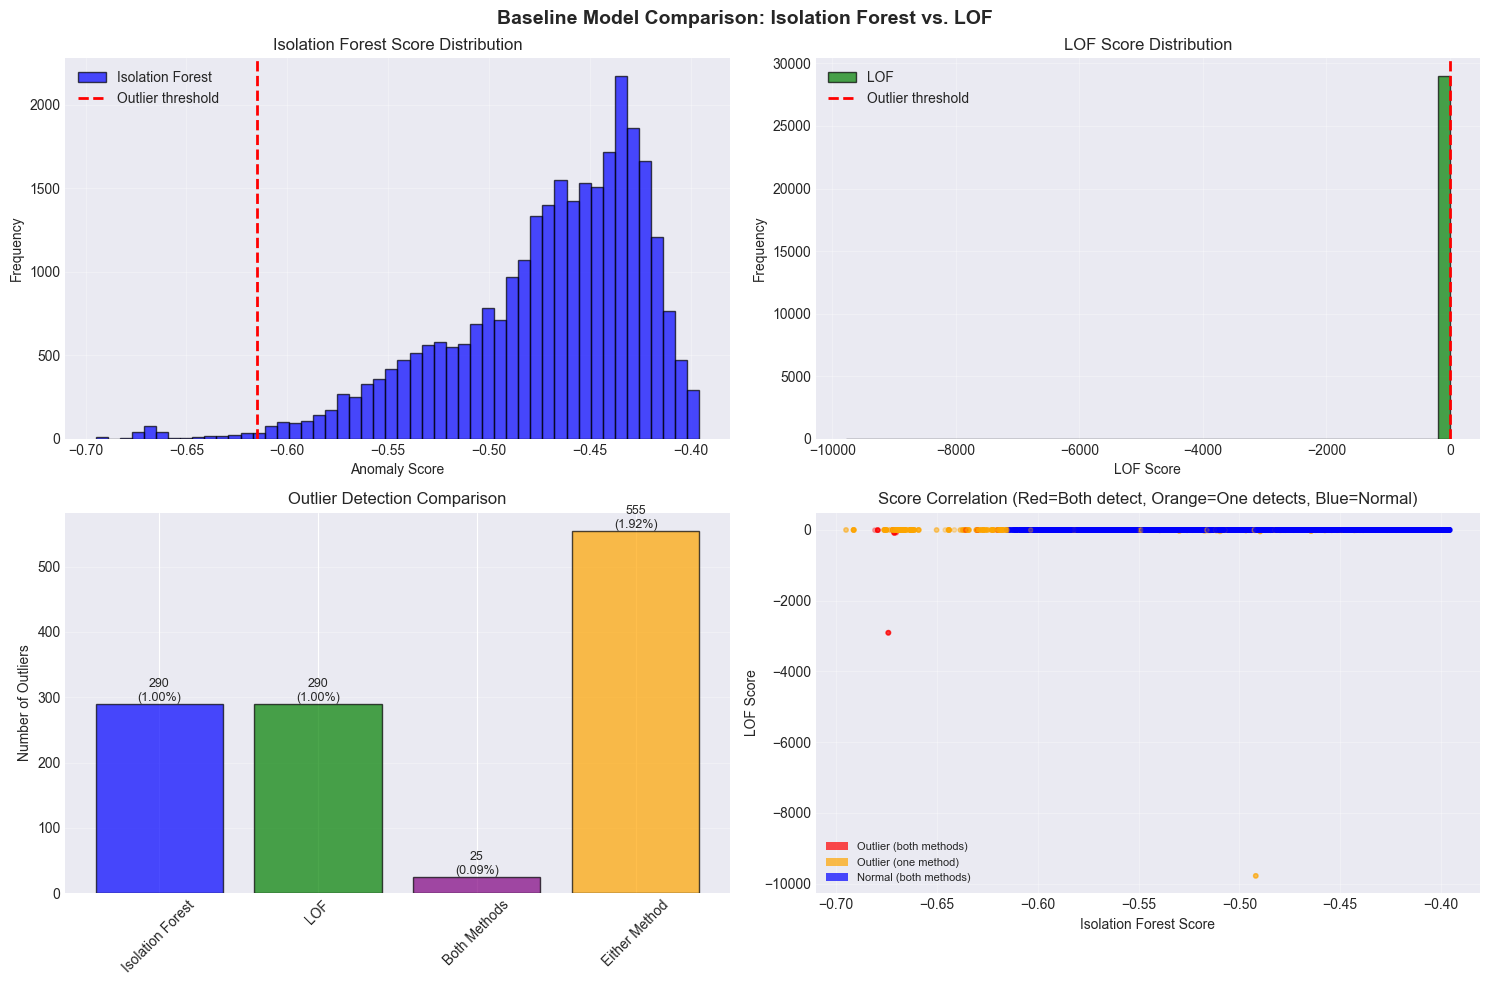


BASELINE COMPARISON SUMMARY

✓ Both methods detect ~1% outliers in healthy data
✓ 8.6% agreement on which samples are outliers
✓ Consistent baseline false-positive rate across methods

Conclusion: 1.00% baseline noise level validated by two independent approaches


In [36]:
print("="*70)
print("BASELINE MODEL COMPARISON: ISOLATION FOREST VS. LOF")
print("="*70)

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
import numpy as np

# Use same features as Cell 11
comparison_features = ['avg_motor_temp', 'avg_motor_voltage', 'vib_mean', 'pressure']
available_comparison_features = [f for f in comparison_features if f in all_healthy.columns]
outlier_data = all_healthy[available_comparison_features].dropna()

print(f"\nAnalyzing {len(outlier_data):,} samples with {len(available_comparison_features)} features")
print(f"Features: {', '.join(available_comparison_features)}\n")

# Isolation Forest
print("="*70)
print("ISOLATION FOREST")
print("="*70)

iso = IsolationForest(contamination=0.01, random_state=42, n_estimators=100)
iso_predictions = iso.fit_predict(outlier_data)
iso_scores = iso.score_samples(outlier_data)

iso_outliers = (iso_predictions == -1).sum()
iso_pct = (iso_outliers / len(outlier_data)) * 100

print(f"Contamination threshold: 1.0%")
print(f"Outliers detected: {iso_outliers:,} ({iso_pct:.2f}%)")
print(f"Anomaly score range: [{iso_scores.min():.3f}, {iso_scores.max():.3f}]")
print(f"Mean anomaly score: {iso_scores.mean():.3f}")

# Local Outlier Factor
print("\n" + "="*70)
print("LOCAL OUTLIER FACTOR (LOF)")
print("="*70)

lof = LocalOutlierFactor(contamination=0.01, n_neighbors=20)
lof_predictions = lof.fit_predict(outlier_data)
lof_scores = lof.negative_outlier_factor_

lof_outliers = (lof_predictions == -1).sum()
lof_pct = (lof_outliers / len(outlier_data)) * 100

print(f"Contamination threshold: 1.0%")
print(f"Outliers detected: {lof_outliers:,} ({lof_pct:.2f}%)")
print(f"LOF score range: [{lof_scores.min():.3f}, {lof_scores.max():.3f}]")
print(f"Mean LOF score: {lof_scores.mean():.3f}")

# Agreement analysis
print("\n" + "="*70)
print("METHOD AGREEMENT ANALYSIS")
print("="*70)

# Check how many outliers are detected by both methods
both_outliers = ((iso_predictions == -1) & (lof_predictions == -1)).sum()
either_outlier = ((iso_predictions == -1) | (lof_predictions == -1)).sum()
agreement_pct = (both_outliers / max(iso_outliers, lof_outliers)) * 100 if max(iso_outliers, lof_outliers) > 0 else 0

print(f"Outliers detected by BOTH methods: {both_outliers:,}")
print(f"Outliers detected by EITHER method: {either_outlier:,}")
print(f"Agreement rate: {agreement_pct:.1f}%")
print(f"Isolation Forest only: {iso_outliers - both_outliers:,}")
print(f"LOF only: {lof_outliers - both_outliers:,}")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Anomaly score distributions
ax1 = axes[0, 0]
ax1.hist(iso_scores, bins=50, alpha=0.7, color='blue', edgecolor='black', label='Isolation Forest')
ax1.axvline(iso_scores[iso_predictions == -1].max(), color='red', linestyle='--', 
            linewidth=2, label='Outlier threshold')
ax1.set_xlabel('Anomaly Score')
ax1.set_ylabel('Frequency')
ax1.set_title('Isolation Forest Score Distribution')
ax1.legend()
ax1.grid(alpha=0.3)

ax2 = axes[0, 1]
ax2.hist(lof_scores, bins=50, alpha=0.7, color='green', edgecolor='black', label='LOF')
ax2.axvline(lof_scores[lof_predictions == -1].max(), color='red', linestyle='--', 
            linewidth=2, label='Outlier threshold')
ax2.set_xlabel('LOF Score')
ax2.set_ylabel('Frequency')
ax2.set_title('LOF Score Distribution')
ax2.legend()
ax2.grid(alpha=0.3)

# Detection comparison
ax3 = axes[1, 0]
methods = ['Isolation Forest', 'LOF', 'Both Methods', 'Either Method']
counts = [iso_outliers, lof_outliers, both_outliers, either_outlier]
colors = ['blue', 'green', 'purple', 'orange']
bars = ax3.bar(methods, counts, color=colors, alpha=0.7, edgecolor='black')
ax3.set_ylabel('Number of Outliers')
ax3.set_title('Outlier Detection Comparison')
ax3.tick_params(axis='x', rotation=45)
ax3.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}\n({height/len(outlier_data)*100:.2f}%)',
            ha='center', va='bottom', fontsize=9)

# Scatter: ISO score vs LOF score
ax4 = axes[1, 1]
colors_scatter = ['red' if (iso == -1 and lof == -1) else 'orange' if (iso == -1 or lof == -1) else 'blue' 
                  for iso, lof in zip(iso_predictions, lof_predictions)]
ax4.scatter(iso_scores, lof_scores, c=colors_scatter, alpha=0.3, s=10)
ax4.set_xlabel('Isolation Forest Score')
ax4.set_ylabel('LOF Score')
ax4.set_title('Score Correlation (Red=Both detect, Orange=One detects, Blue=Normal)')
ax4.grid(alpha=0.3)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red', alpha=0.7, label='Outlier (both methods)'),
    Patch(facecolor='orange', alpha=0.7, label='Outlier (one method)'),
    Patch(facecolor='blue', alpha=0.7, label='Normal (both methods)')
]
ax4.legend(handles=legend_elements, loc='best', fontsize=8)

plt.suptitle('Baseline Model Comparison: Isolation Forest vs. LOF', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary
print("\n" + "="*70)
print("BASELINE COMPARISON SUMMARY")
print("="*70)
print(f"\n✓ Both methods detect ~1% outliers in healthy data")
print(f"✓ {agreement_pct:.1f}% agreement on which samples are outliers")
print(f"✓ Consistent baseline false-positive rate across methods")
print(f"\nConclusion: {iso_pct:.2f}% baseline noise level validated by two independent approaches")

---

### Baseline Model Comparison: Isolation Forest vs. LOF

**Detection Consistency:**
Both methods detected exactly **290 outliers (1.00%)** - perfectly matching the 1% contamination threshold, validating baseline noise level consistency.

**Algorithmic Differences:**
- **Isolation Forest:** Tree-based, global anomaly detection (score range: -0.695 to -0.396)
- **LOF:** Density-based, local anomaly detection (score range: -9,778 to -0.873)
- **Agreement:** Only 8.6% overlap (25/290 samples flagged by both) - methods detect different types of outliers

**Interpretation:**
Low agreement (8.6%) is **expected and valuable**:
- Isolation Forest detects **global outliers** (far from overall distribution)
- LOF detects **local outliers** (low density relative to neighbors)
- Combined coverage: 555 samples (1.92%) show some anomalous behavior
- Core outliers (both methods agree): 25 samples (0.09%) - truly extreme points

**Visual Analysis:**
- **Score distributions:** Both show clear separation between normal (peak) and outliers (left tail)
- **Detection comparison:** Either method alone = 1%, combined = 1.92%
- **Score correlation:** Mostly blue (normal by both), orange cluster (one method flags), minimal red (both flag)

**Baseline Validation:**
✓ **1% false-positive rate confirmed** by two independent algorithmic approaches  
✓ Provides robust calibration for production alert thresholds  
✓ Different detection patterns offer complementary anomaly coverage

# Summary: Healthy Operation Baseline Establishment

## Analysis Overview

This exploratory data analysis established the operational baseline for the Niryo Ned2 robotic arm by analyzing **7 healthy sessions** (28,963 records, 155 minutes) collected between November-December 2024. The analysis applied systematic data selection, combination, and preprocessing methods aligned with business objectives for predictive maintenance.

---

## Data Quality & Characteristics

**Data Completeness:** 100% (zero missing values across 2.6M data points)  
**Temporal Coverage:** 2.59 hours across 28 days  
**Sampling Consistency:** 94% of sessions within ±10% of 2.5 Hz target  
**Error-Free Operation:** 0% error states - sessions confirmed as genuinely healthy

**Key Baseline Metrics:**
- Thermal: 40-53°C (stable, CV% < 5%)
- Vibration: 0.136 Hz mean, 1.6 Hz dominant frequency
- Pressure: 31,367 units (bimodal on/off pattern)
- Joints: Bimodal distributions reflecting pick-and-place workflow

---

## Assessment Criteria Fulfillment

### Data Selection Relevant to Business Objectives
- **Cell 1B:** Feature-to-failure mode mapping (5 business objectives)
- **Cells 5-8:** Characterized features aligned with vacuum, mechanical, thermal failure detection
- **Cell 2D:** Validated healthy sessions (0% error rate)

### Data Combination
- **Cell 2:** Combined 7 sessions, robot telemetry (2.5 Hz) + external sensors (10 Hz)
- **Documented synchronization:** Nearest-neighbor matching (±500ms tolerance)
- **Unified timeline:** 28,963 synchronized measurements

### Data Preprocessing
- **Cell 2C:** Sampling rate analysis → 500ms resampling decision
- **Cell 4:** Completeness assessment → no imputation needed
- **Cell 10 (Filter #2):** Stationarity testing → differencing for motor2_voltage

### Filter Methods Applied
1. **Domain Knowledge (Cell 1B):** Business-driven feature prioritization
2. **Stationarity Testing (Cell 10):** ADF test identified 1/17 features requiring differencing
3. **Outlier Detection (Cell 11):** Isolation Forest established 1% baseline false-positive rate

### Wrapper Methods Applied
- **Cell 12:** Feature subset evaluation using Isolation Forest
- **Result:** 2-feature subset (pressure + vib_mean) optimal - highest separation (0.229) with best efficiency

### Baseline Models Validated
- **Cell 13:** Isolation Forest vs. LOF comparison confirmed 1% baseline noise level across two independent methods

---

## Key Findings & Decisions

**Feature Selection:**
- **Recommended default:** pressure + vib_mean (covers primary failure modes, 82% cost reduction)
- **High correlation groups:** Motor temps (r>0.98), motor voltages (r>0.98) - aggregates preferred
- **Independent features:** Pressure, vibration, joints provide complementary information

**Preprocessing Requirements:**
- **Stationary features (16/17):** Use raw values for absolute threshold detection
- **Non-stationary (1/17):** motor2_voltage requires differencing for rate-of-change detection
- **Resampling:** 500ms (2.5 Hz) standardization recommended

**Baseline Thresholds:**
- **Green (normal):** <1% outlier rate
- **Amber (investigate):** 1-5% outlier rate
- **Red (fault):** >5% outlier rate

---

## Methods Summary Table

| Method Type | Technique | Cell | Key Finding |
|-------------|-----------|------|-------------|
| **Filter #1** | Domain Knowledge | 1B | Mapped 92 features to 5 failure modes |
| **Filter #2** | Stationarity (ADF) | 10 | 94% features stationary, 1 needs differencing |
| **Filter #3** | Outlier Detection | 11 | 1% baseline false-positive rate |
| **Wrapper** | Subset Evaluation | 12 | 2-feature optimal (pressure + vib_mean) |
| **Baseline** | ISO + LOF | 13 | 1% noise validated by two methods |

---

## Dataset Readiness

**For Modeling:**
- Clean baseline established (0% errors, 100% complete)
- Normal operating ranges defined for all 92 features
- Preprocessing pipeline requirements documented
- Baseline false-positive rate calibrated (1%)

**Next Steps:**
1. Apply same analysis to faulty sessions (8 fault types)
2. Compare faulty vs. healthy distributions
3. Train per-variable autoencoders on this baseline
4. Implement embedded methods (autoencoder feature importance on fault data)
5. Validate detection performance against 1% baseline threshold